# Set up simulations and data

## read in libraries

In [56]:
import sys
sys.path.append(r"C:\GitHubRepos\APSIMTools\GraphLib")

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# graph models
from apsim_tools.graphing import (
    plot_obs_pred_by_branch,
    plot_stage_timeseries
)

from apsim_tools.style import ( 
    Colors, 
    Markers,
    Lines
)

from apsim_tools.runner import (
    load_all,
    validate_run_branches,
    to_tidy
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Branch and file Settings

In [57]:
# ======================
# CONFIG
# ======================
BRANCHES = {
    "master": "Lentil_Model_NaPA",
}

# ======================
# RUN CONTROL - Specify which branches to (re)run
# ======================

# Options:
#RUN_BRANCHES = []                    # run nothing (use existing DBs)
RUN_BRANCHES = list(BRANCHES.keys())   # run all branches
#RUN_BRANCHES = ["master"]
#RUN_BRANCHES = ["working"]
#RUN_BRANCHES = ["working V2"]

REPO_PATH = Path(r"C:\GitHubRepos\ApsimX")

SIM_FILES = [
    #Path(REPO_PATH) / 'Prototypes/Lentil/Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/FAHMA/FAHMA_Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2019_NSW_Greenethorpe_Mixed_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Kalkee_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Riverton_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_Methul_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Pinery_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Dooen_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Qld_Gatton_Mixed_Light.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_NSW_Greenethorpe_Mixed_NFix.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.apsimx'
]


CONFIG = {
    "branches": BRANCHES,
    "run_branches": RUN_BRANCHES,
    "sim_files": SIM_FILES,
    "repo_path": Path(r"C:\GitHubRepos\ApsimX"),
    "apsim_exe": r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe",
    "apsim_solution": r"C:\GitHubRepos\ApsimX\ApsimX.sln",
    "stage_var": "Lentil.Phenology.Stage",
    "stage_name_var": "Lentil.Phenology.CurrentStageName",
    "harvest_stage": "HarvestRipe",
    "cultivar_col": "Lentil.SowingData.Cultivar"
}

validate_run_branches(config=CONFIG)

## additional index mapping

In [58]:
# Specifiy map for cultivars to winter or spring type
project_group={
 'Caragabal19':'Historic',
 'Emerald19':'Historic',
 'Gatton19':'Historic',
 'Greenethorpe19':'Historic',
 'GreenethorpePhen19':'Historic',
 'Mildura19':'Historic',
 'Millmerran19':'Historic',
 'Walgett19':'Historic',
 'Wellcamp25':'FAHMA',
 'Roberts1988':'ContEnv',
 'Roberts1986':'ContEnv',
 'Summerfield1985':'ContEnv',
 'Rajandran2022':'ContEnv',
 'Dooen2001':'Historic',
 'Roseworthy':'Historic',
 'Gatton24':'FAHMA',
 'Gatton23':'FAHMA',
 'ForestHill25':'FAHMA',
 '2019_NSW_Greenethorpe_Mixed_Detailed':'NaPA',
 '2022_Vic_Kalkee_Lentil_Detailed':'NaPA',
 '2022_SA_Riverton_Lentil_Detailed':'NaPA',
 '2022_NSW_WaggaWagga_Lentil_Detailed':'NaPA',
 '2022_NSW_Methul_Lentil_Satellite':'NaPA',
 '2022_Vic_Ouyen_Lentil_Satellite':'NaPA',
 '2022_NSW_RankinsSprings_Lentil_Satellite':'NaPA',
 '2022_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2023_SA_Pinery_Lentil_Detailed':'NaPA',
 '2023_Vic_Dooen_Lentil_Detailed':'NaPA',
 '2023_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2023_Vic_Ouyen_Lentil_Satellite':'NaPA',
 '2023_Qld_Gatton_Mixed_Light':'NaPA',
 '2024_NSW_Greenethorpe_Mixed_NFix':'NaPA',
 '2024_SA_Warnertown_Lentil_Satellite':'NaPA',
 '2024_Vic_Walpeup_Lentil_Satellite':'NaPA',
}

WaterIndex = pd.read_pickle('IrrigIndex')
sim_water_map = dict(zip(WaterIndex["SimulationName"], WaterIndex["WaterGroup"]))

# Pack maps together ready to be inserted as indexes 
additional_index_maps = {
    "ProjectGroup": {
        "source": "Experiment",
        "map": project_group
    },
    "WaterTrt": {
        "source": "SimulationName",
        "map": sim_water_map
    }
}

In [59]:

# # get unique simulation names
# sims = tidy["SimulationName"].drop_duplicates()

# # classification function
# def classify_sim(name):
#     s = str(name).lower()

#     if "rainfed" in s:
#         return "RainFed"
#     elif "irrigated" in s:
#         return "Irrigated"
#     elif "rainout" in s:
#         return "RainOut"
#     else:
#         return "None"

# # build dictionary
# sim_water_map = {sim: classify_sim(sim) for sim in sims}

# df = pd.DataFrame(list(sim_water_map.items()), columns=["SimulationName", "WaterGroup"])

# df.to_pickle('IrrigIndex')

## Write file for command line tool to apply to each .apsimx file to be run.
If you want to make standard modifications to all files run it can be done here

In [60]:
def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """
    report_library = r"C:/GitHubRepos/ApsimX/Prototypes/Lentil/Report_lib.apsimx"
    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    #lines.append(f"delete all [Report]")
    lines.append(f"add [AnalysisReport] from {report_library} to all [Zone]")
    
    # ---------------------------------------------
    # Inject Spectral model into each simulation
    # ---------------------------------------------
    # lines.append("add [Spectral] to all [Zone]")

    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

## Run simulations and read in raw .db data and process into tidy format

In [61]:
# ======================
# EXECUTE PIPELINE
# ======================

# Read in raw data
raw = load_all(config=CONFIG, apply_fn=write_apply_file)#, reset_branch=False)

# ✅ Ensure SimulationName exists (from AnalysisReport)
if "Simulation.Name" in raw.columns:
    raw = raw.rename(columns={"Simulation.Name": "SimulationName"})

# ✅ Convert to tidy format
tidy = to_tidy(raw, config=CONFIG, additional_index_maps=additional_index_maps)

🔄 Resetting tracked files only

▶ Running APSIM [master]: FAHMA_Lentil.apsimx
▶ Running APSIM: FAHMA_Lentil.apsimx

FAHMA_Lentil.apsimx tables: ['_Factors', '_InitialConditions', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', 'HarvestObsPred', '_PredictedObserved', 'DailyReport', 'SowingReport', 'AnalysisReport', '_Units', 'Observed', 'DailyObsPred']
✅ Obs filtered by SimulationID: 364/364 rows kept

▶ Running APSIM [master]: 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx
▶ Running APSIM: 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx

2019_NSW_Greenethorpe_Mixed_Detailed.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', '_Messages', 'HarvestReport', '_Simulations', '_Checkpoints', '_Units', '_PredictedObserved', 'AnalysisReport', 'Observed']

⚠️ Missing observed simulations in 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx: 9

⚠️ Dropping unmatched observed simulations in 2019_NSW_Greenethorpe_Mixed_Detailed.apsimx: 164
✅ Obs filtered by SimulationID: 0/1489 rows 

# Harvest predictions

## Phenology

### Emergence DAS

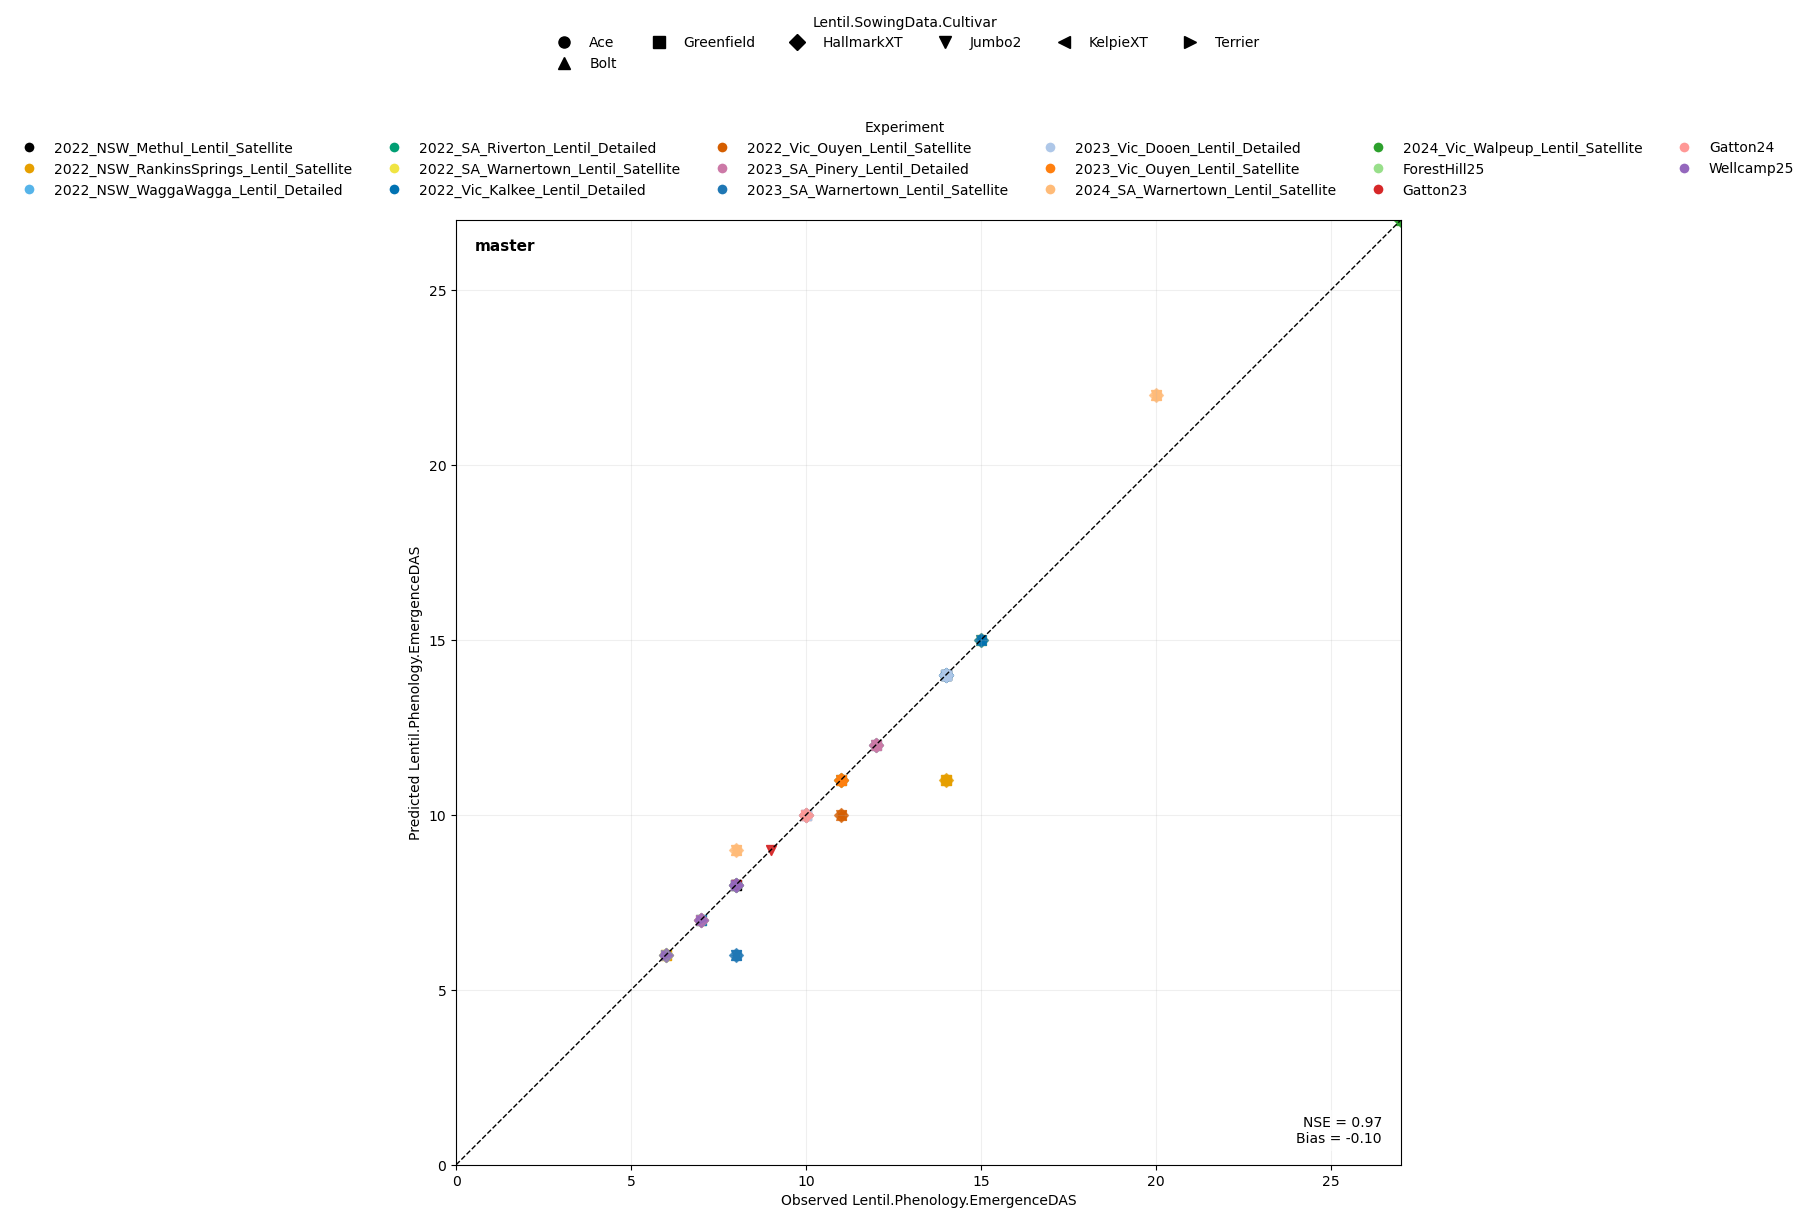

In [62]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.EmergenceDAS",
    mode='harvest',
    #filters = {"Experiment": ["Gatton19"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Budding DAS

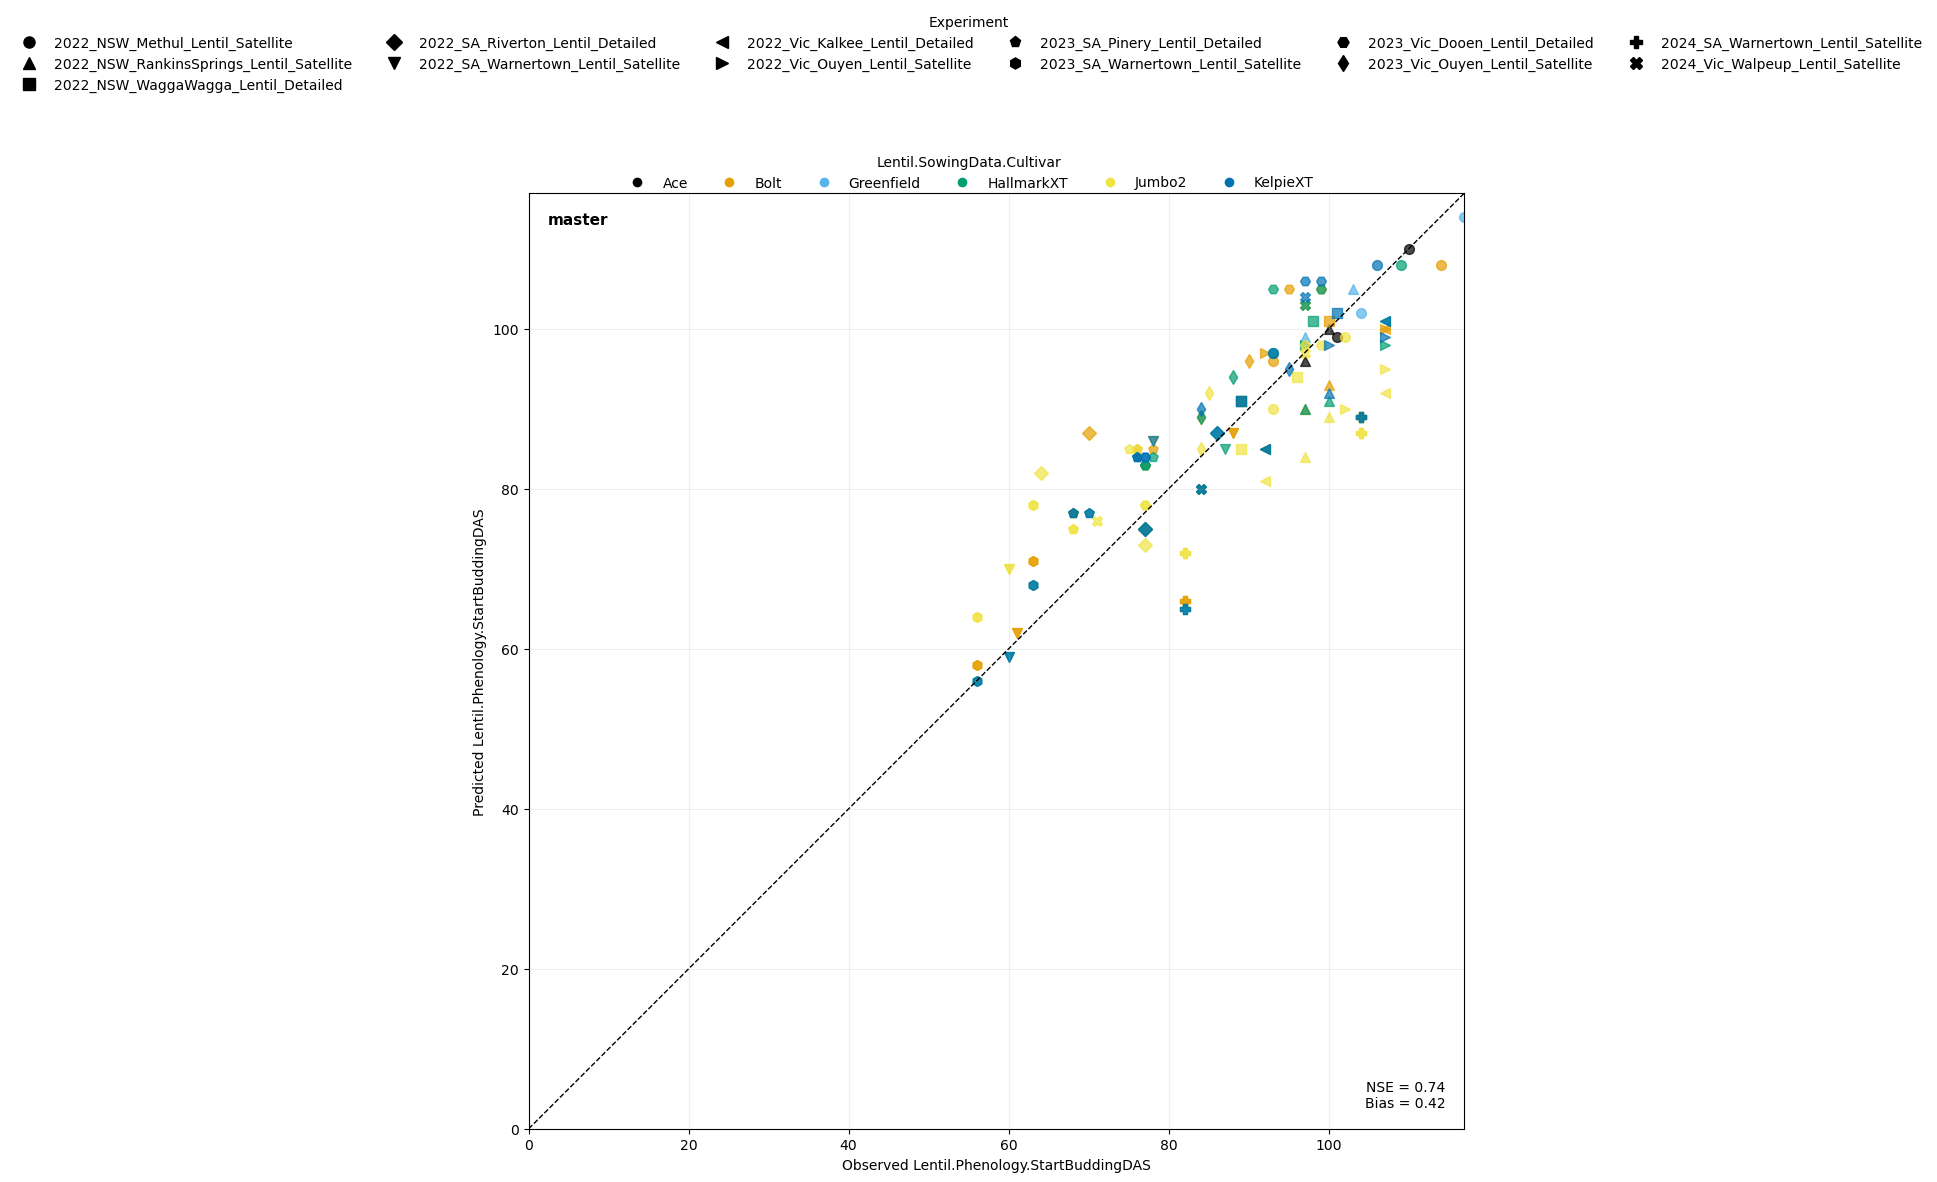

In [63]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.StartBuddingDAS",
    mode='harvest',
    #filters = {"Experiment": ["Gatton19"]},
    marker_by = "Experiment",
    color_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Flowering DAS

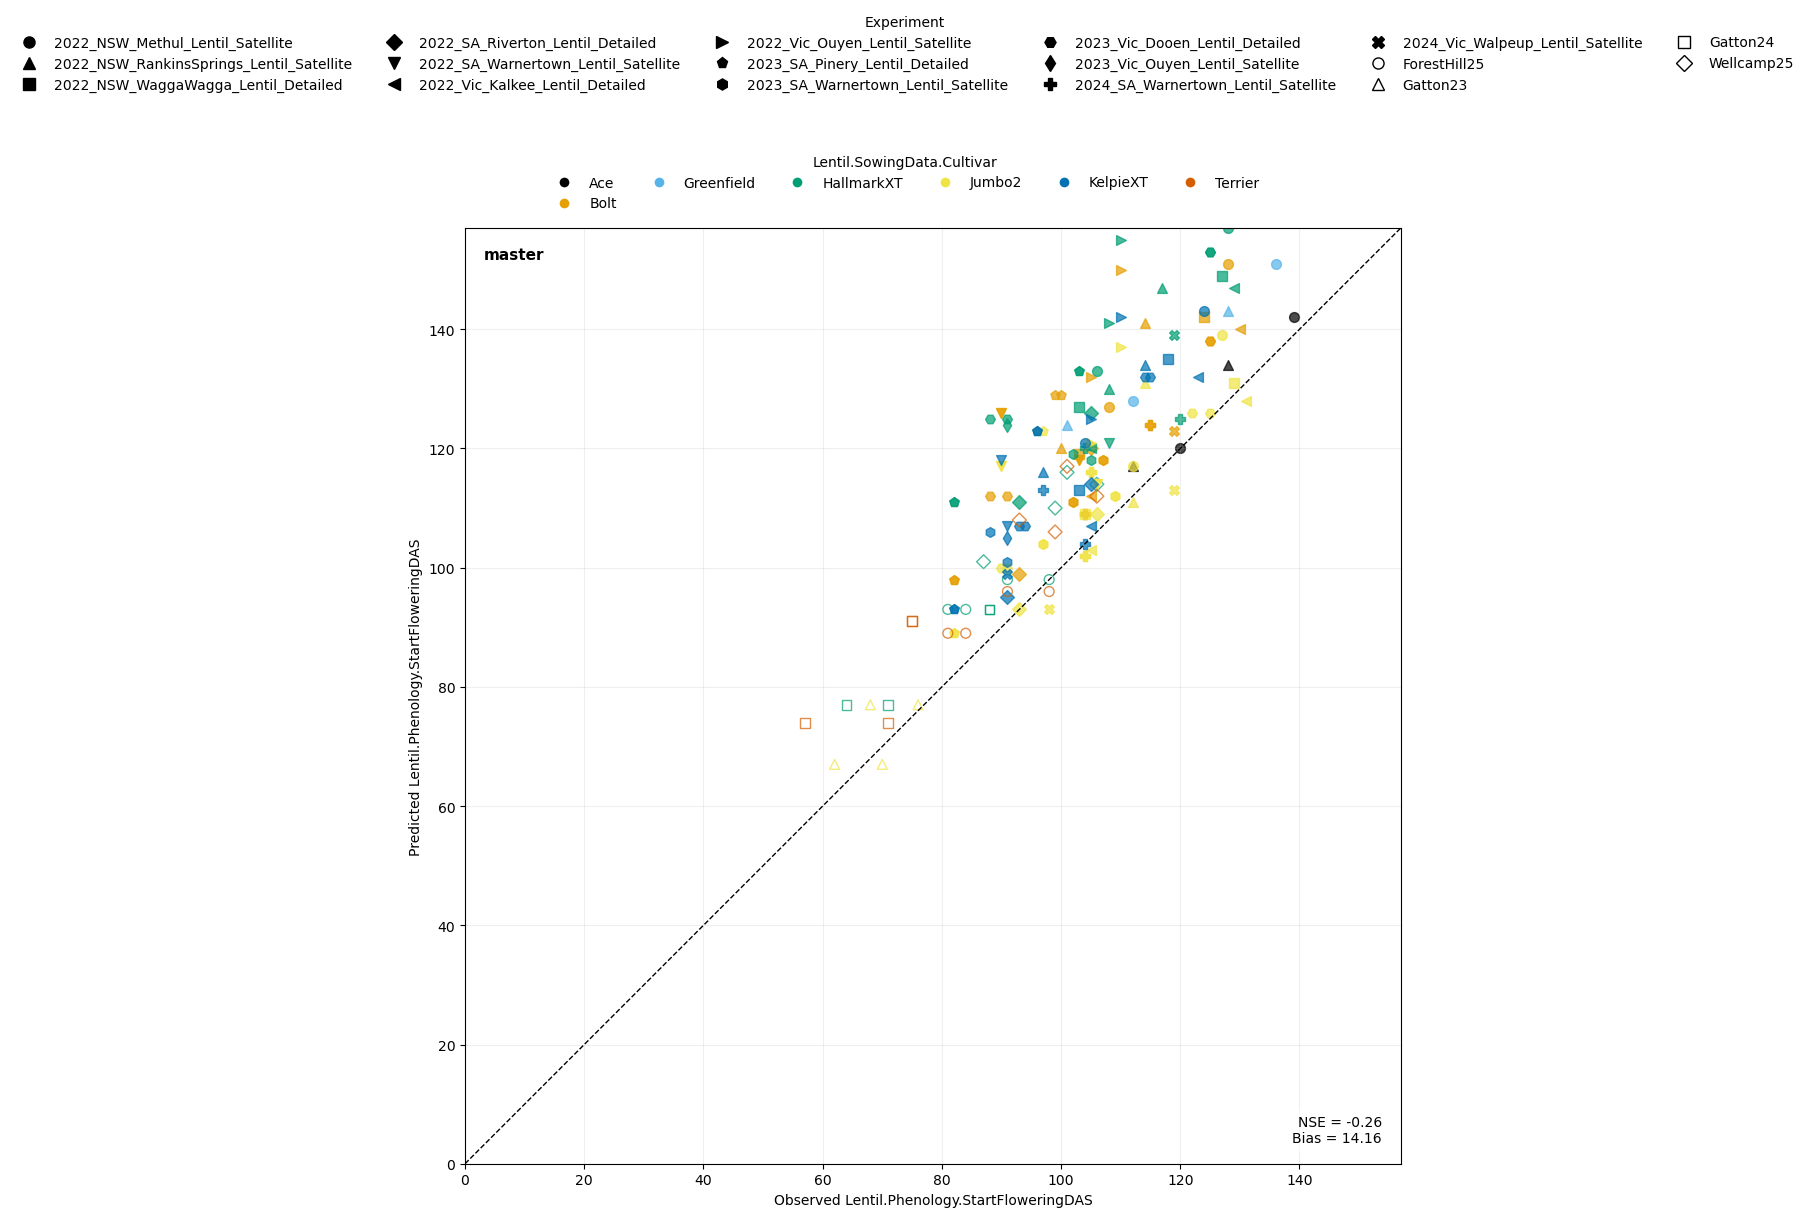

In [64]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.StartFloweringDAS",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    marker_by = "Experiment",
    color_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Podding DAS

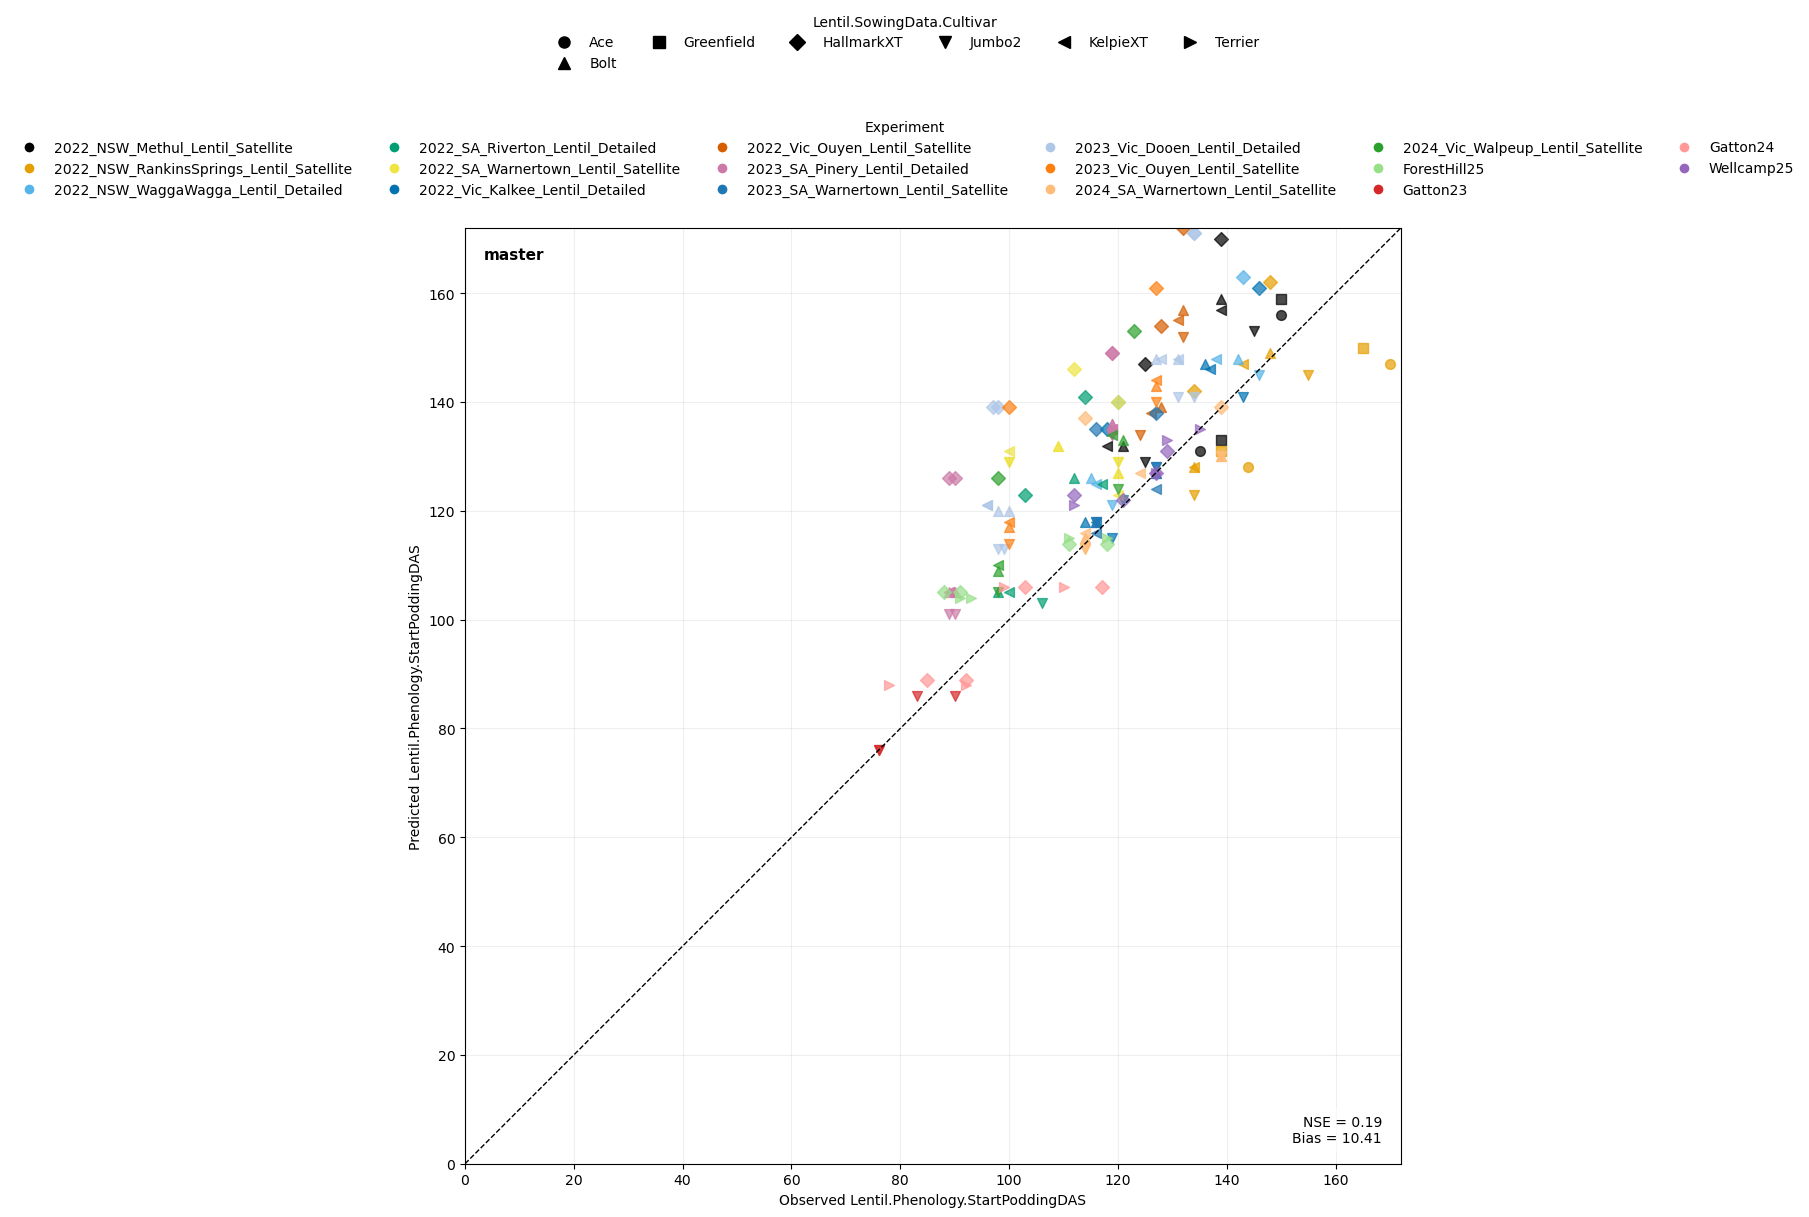

In [65]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.StartPoddingDAS",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Maturity DAS

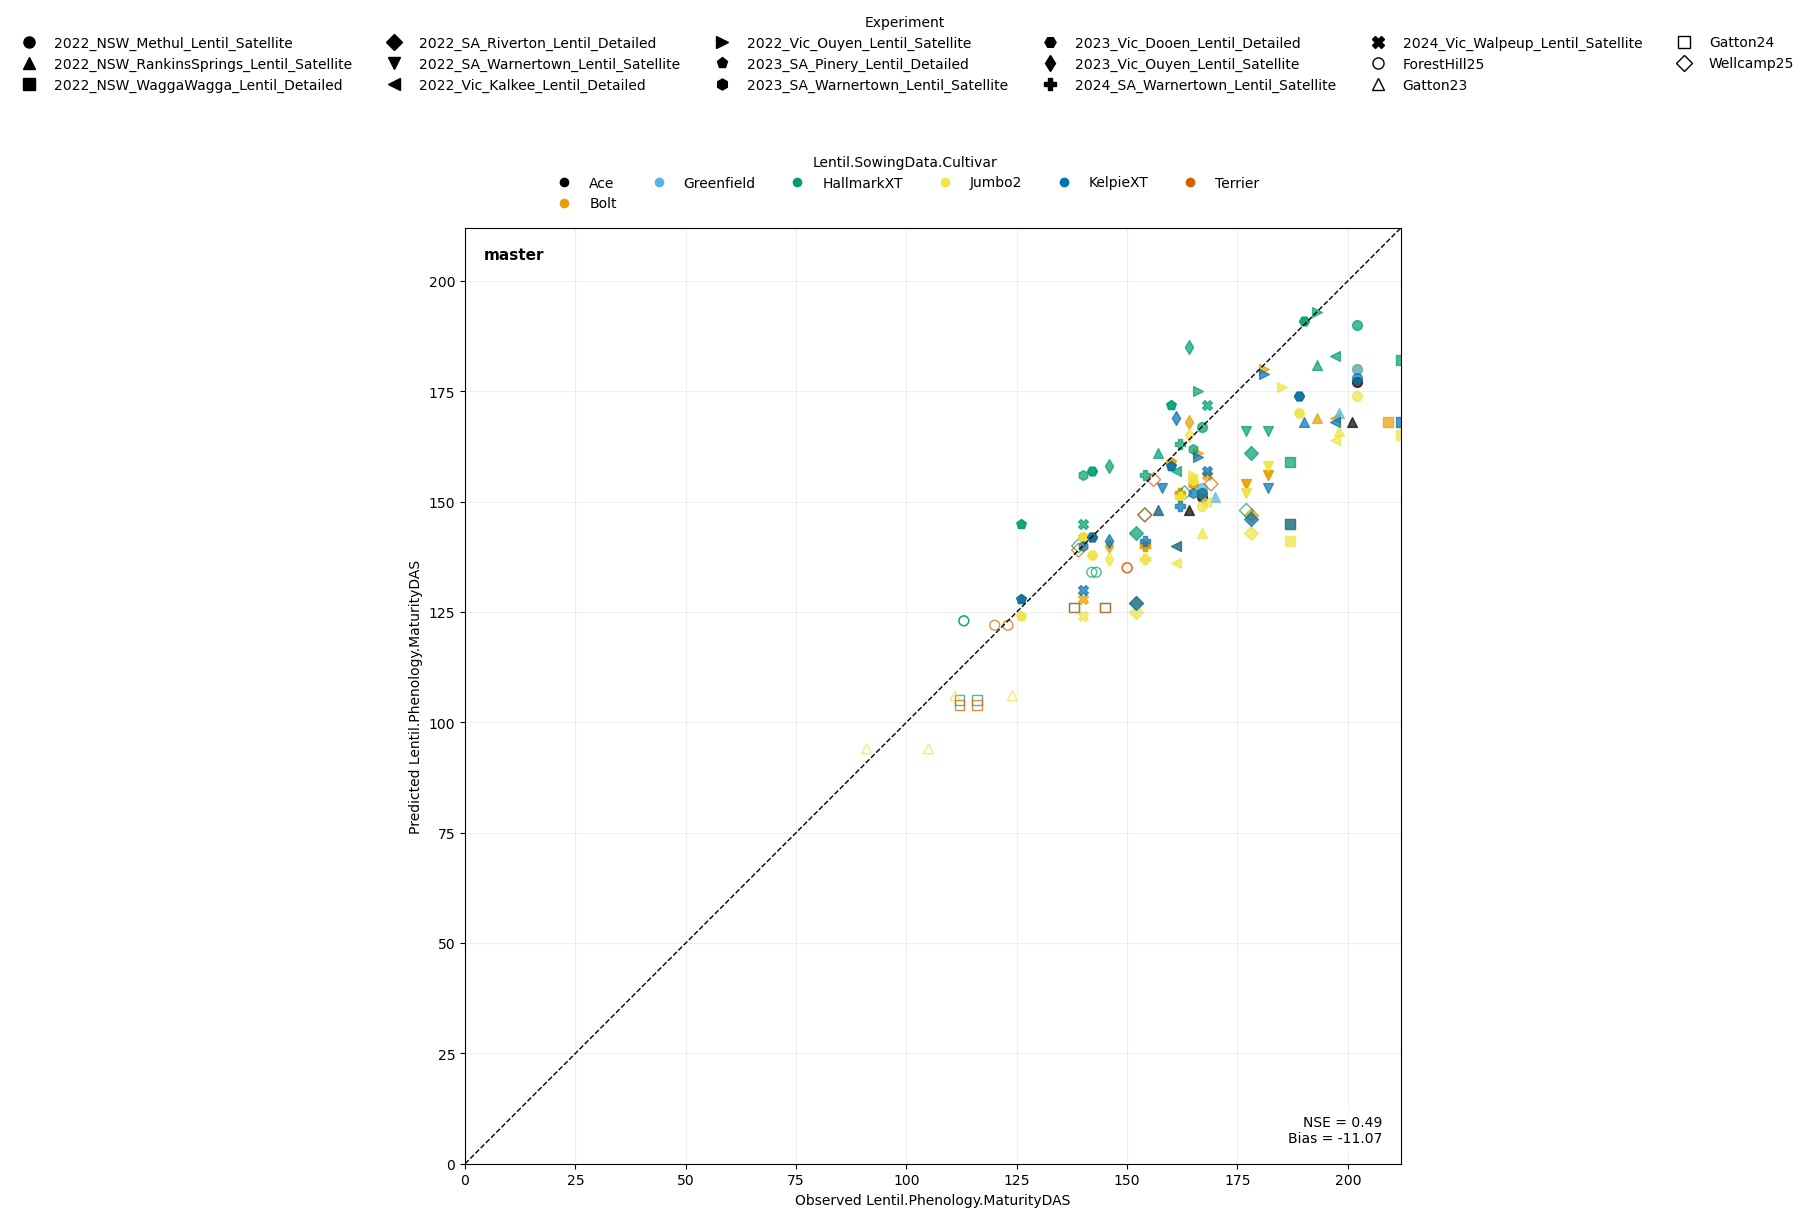

In [66]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Phenology.MaturityDAS",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment",
    size_by=None,
)

## Grain

### Yield (g/m2)

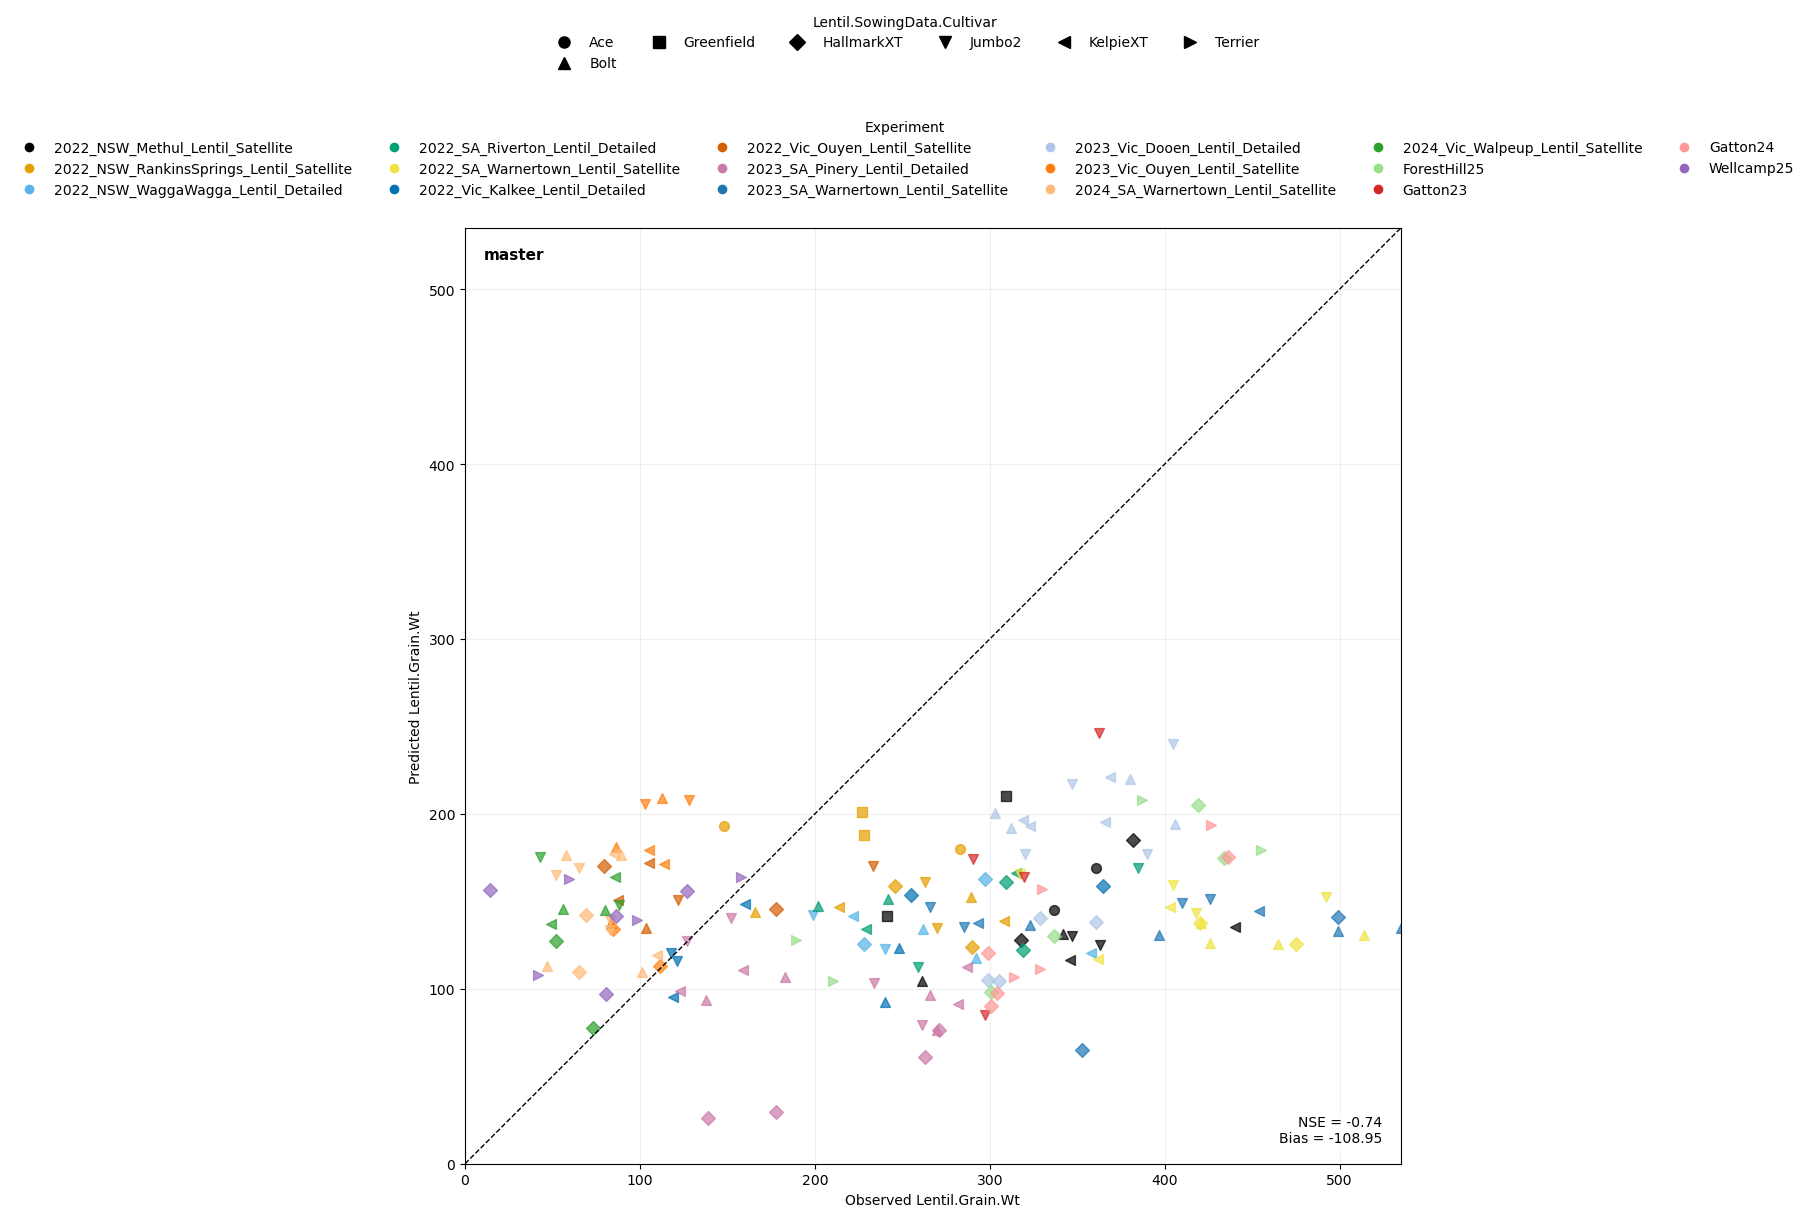

In [67]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Grain.Wt",
    mode='harvest',
    # filters = {"project_group": ["FAHMA"],
    #            "project_group": ["NaPA"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
    #additional_index_maps=additional_index_maps
)

### Grain number

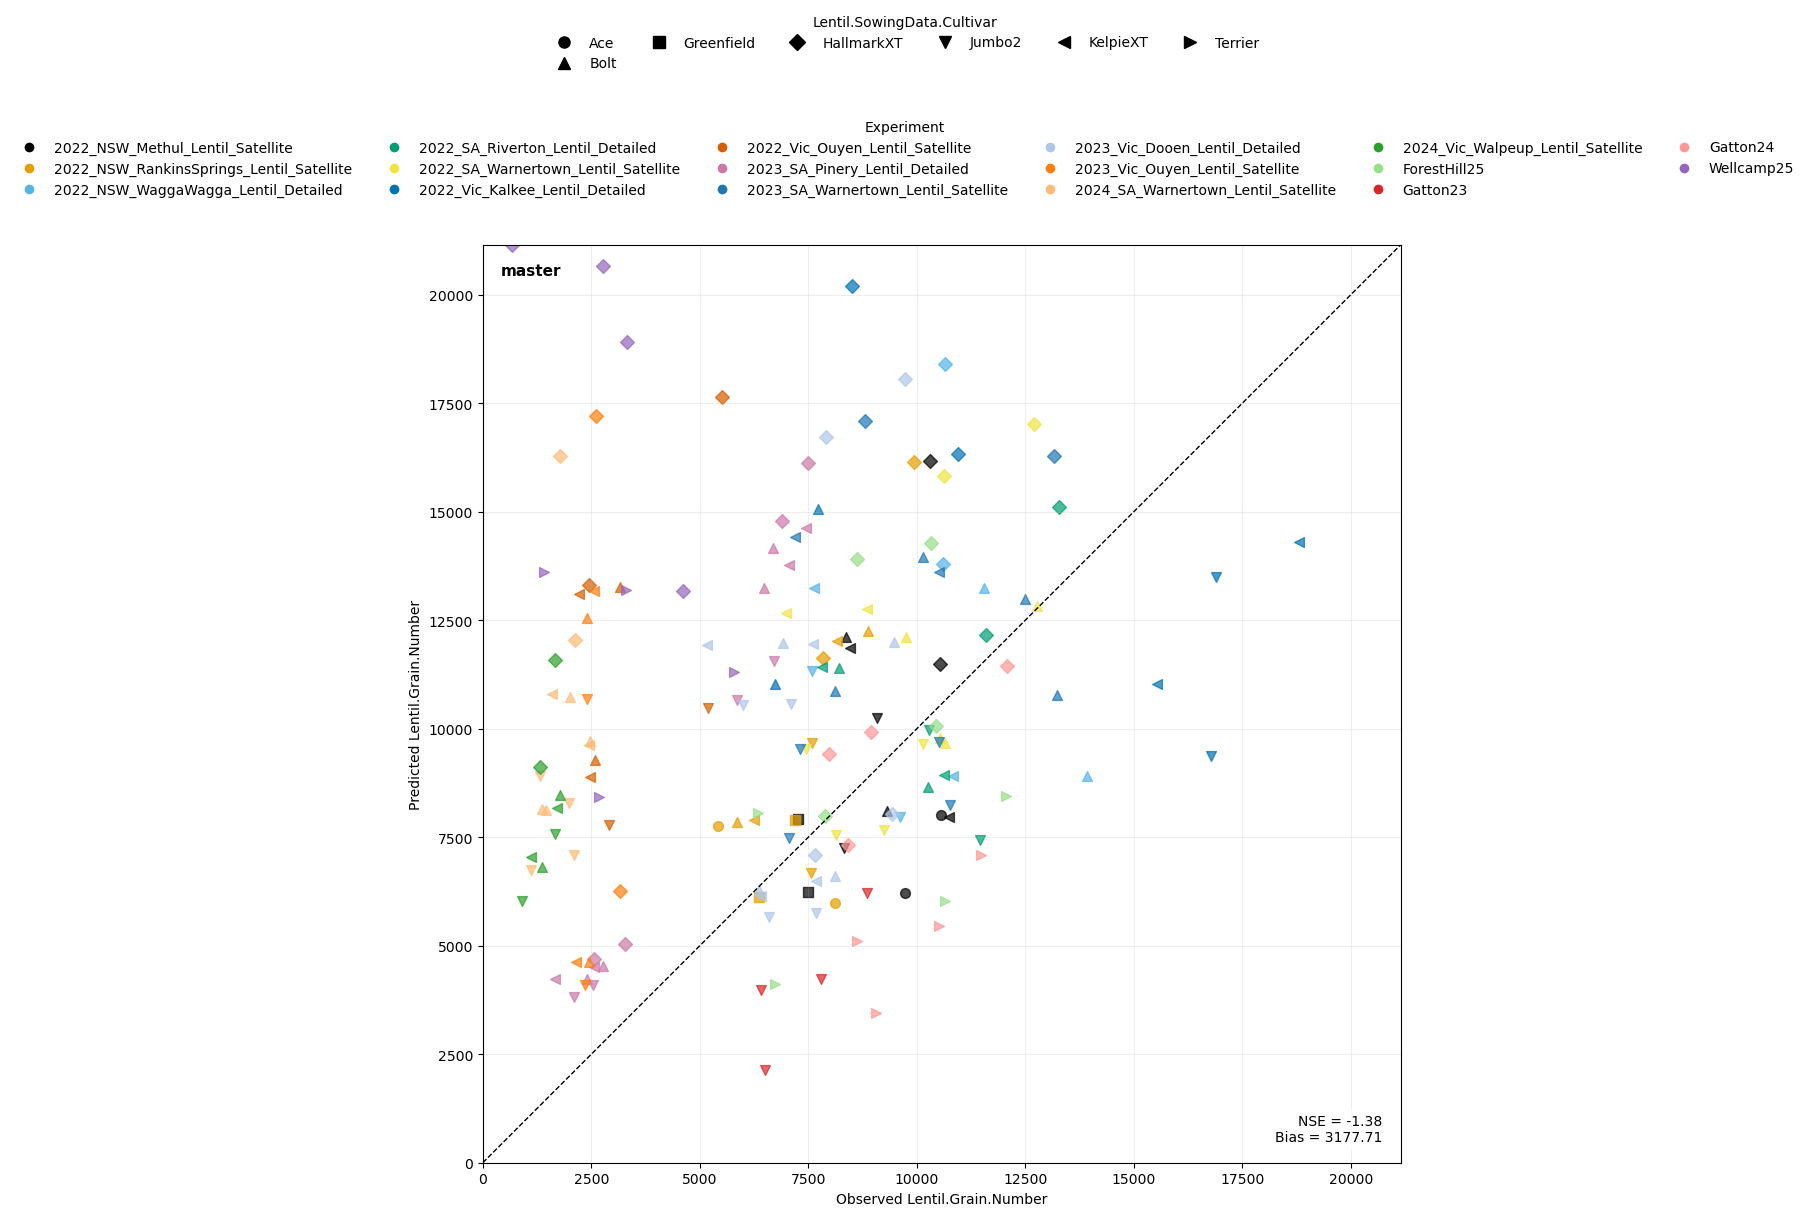

In [68]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Grain.Number",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Grain Size

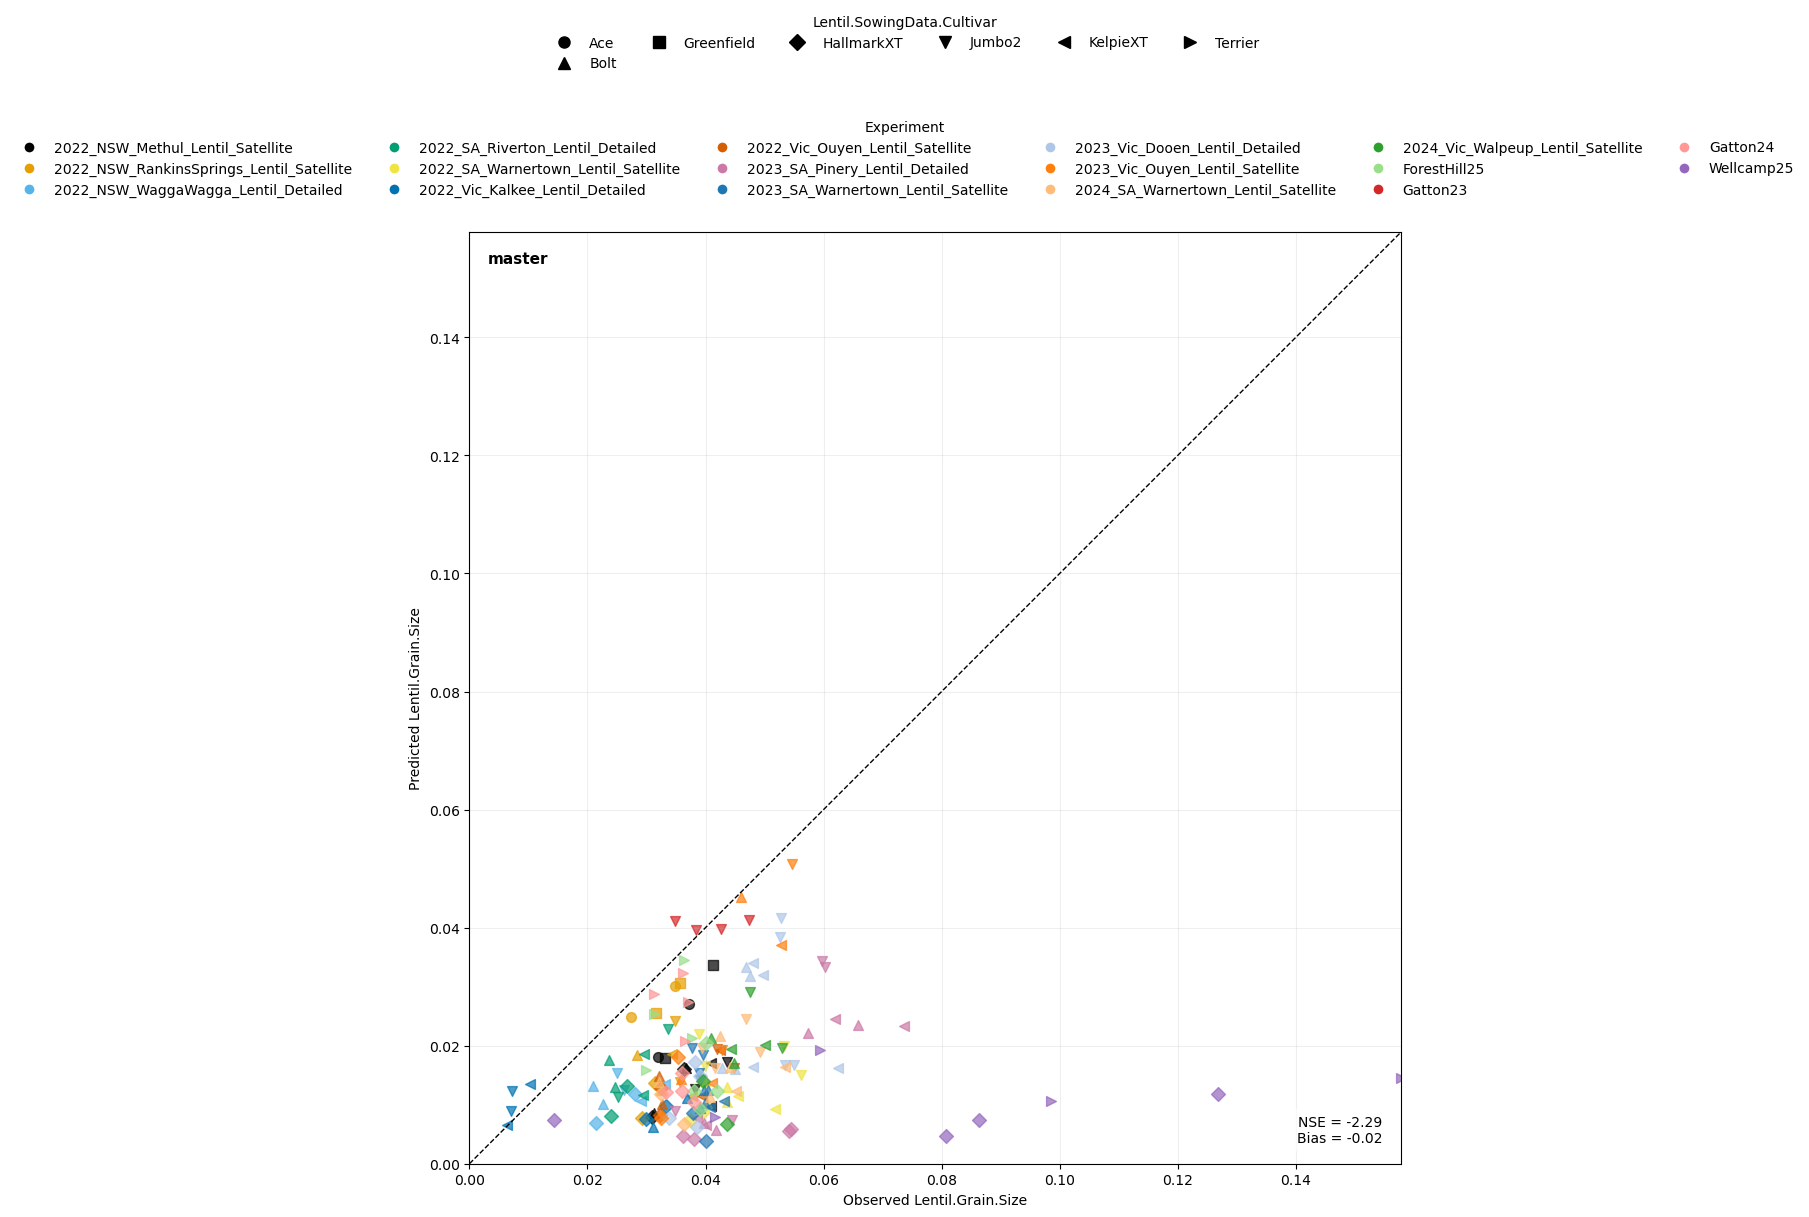

In [69]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Grain.Size",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

### Harvest Index

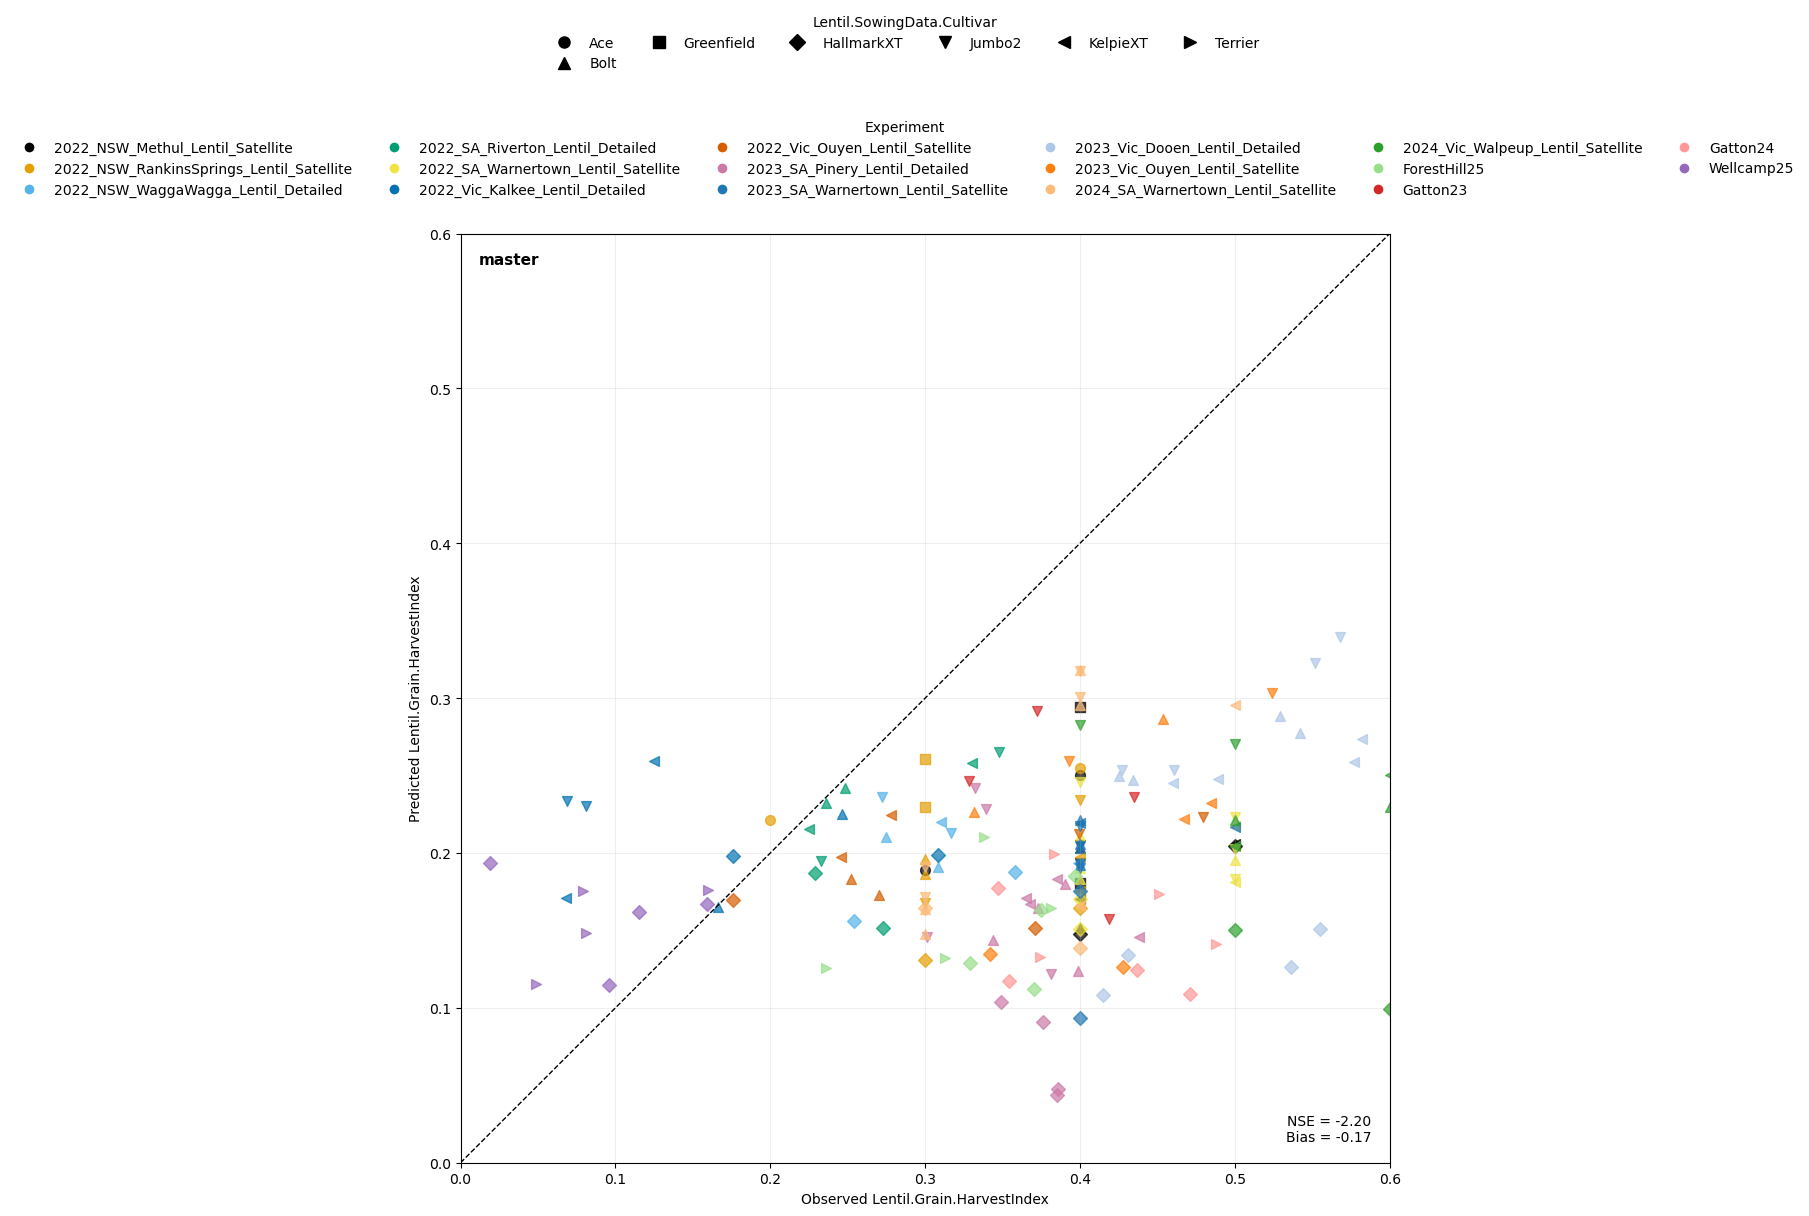

In [70]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Grain.HarvestIndex",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

## Biomas

### Above ground Wt (g/m2)

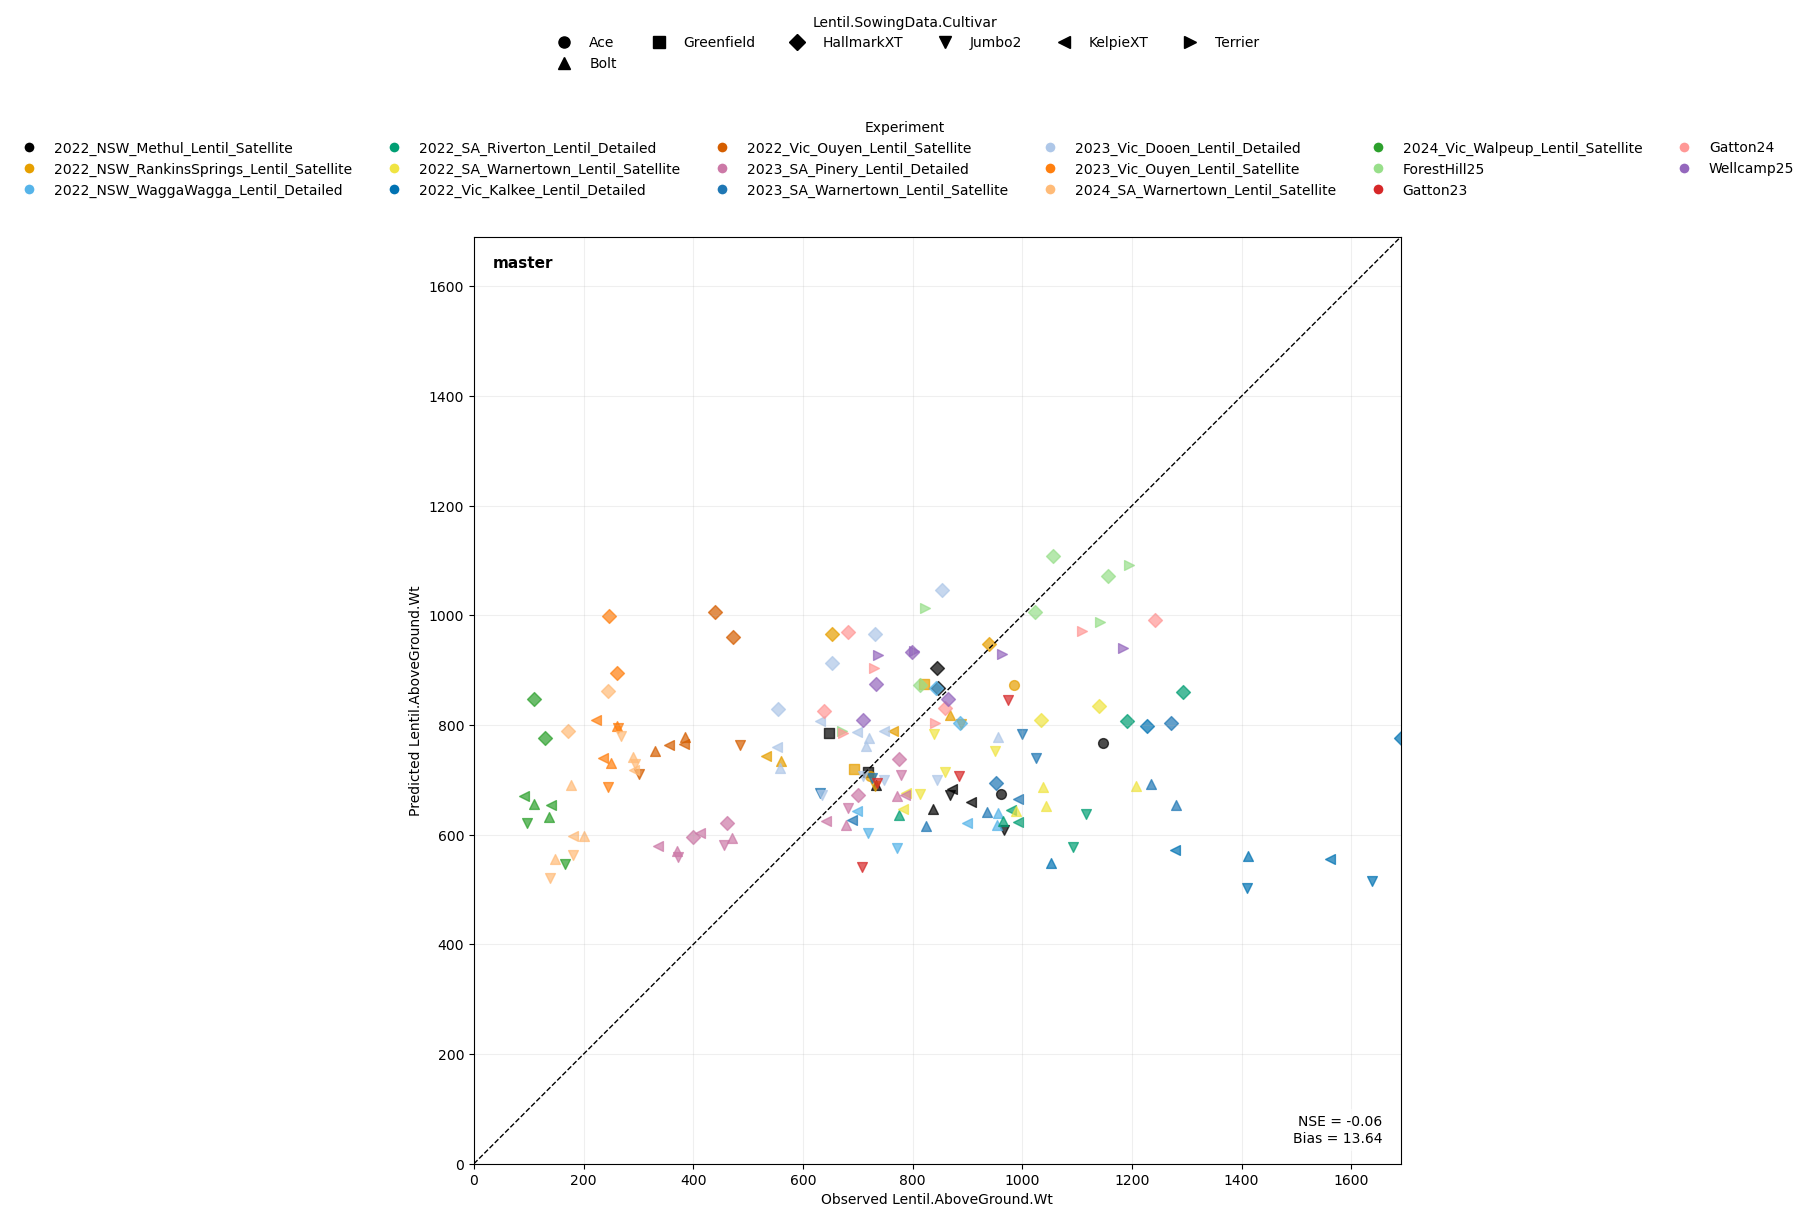

In [71]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.AboveGround.Wt",
    mode='harvest',
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

# Time series plots

## Node Number

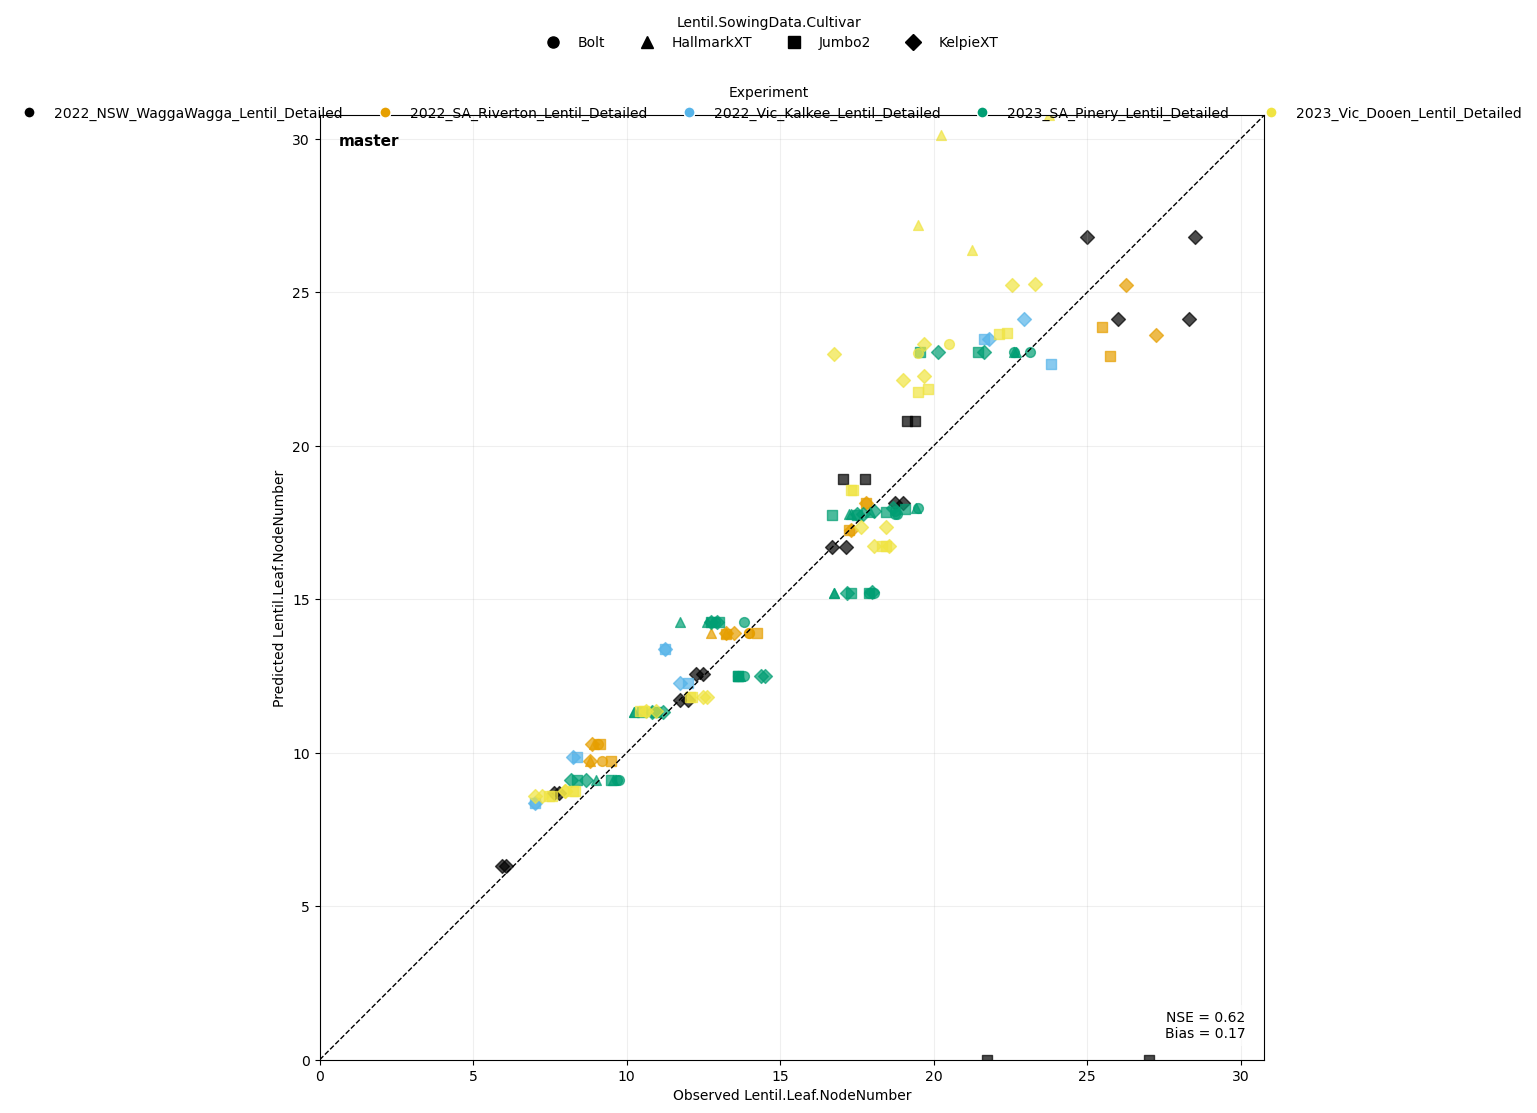

In [72]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.Leaf.NodeNumber",
    mode="daily",
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by =  "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

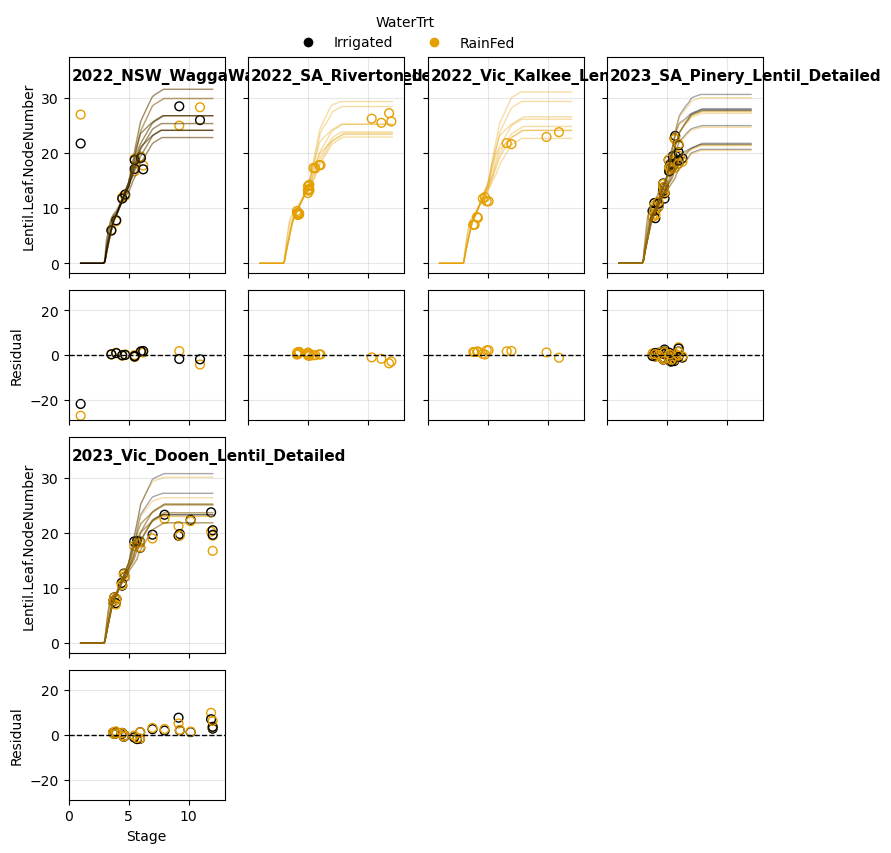

In [73]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Lentil.Leaf.NodeNumber",
    color_by="WaterTrt",
    marker_by=None,
    panels_by="Experiment",
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

In [74]:
tidy[(tidy.variable=="Lentil.Leaf.NodeNumber")&(tidy.type=="obs")].Experiment.drop_duplicates()

825826        2022_Vic_Kalkee_Lentil_Detailed
825934       2022_SA_Riverton_Lentil_Detailed
826056    2022_NSW_WaggaWagga_Lentil_Detailed
826580         2023_SA_Pinery_Lentil_Detailed
826820         2023_Vic_Dooen_Lentil_Detailed
Name: Experiment, dtype: str

In [75]:
tidy[(tidy.variable=="Lentil.Leaf.NodeNumber")&(tidy.type=="obs")].loc[:,"Lentil.SowingData.Cultivar"].drop_duplicates()

825826        Jumbo2
825831      KelpieXT
825934          Bolt
825937    HallmarkXT
Name: Lentil.SowingData.Cultivar, dtype: str

In [76]:
NodeFrame = tidy[(tidy.variable=="Lentil.Leaf.NodeNumber")&(tidy.type=="obs")].groupby(['Lentil.SowingData.Cultivar','file']).count().index.to_frame()

In [77]:
CvList = NodeFrame.index.get_level_values(0).drop_duplicates().values
CvFileDict = {}

for Cv in CvList:
    CvFileDict[Cv] = NodeFrame.loc[Cv,'file'].drop_duplicates().to_list()
CvFileDict

{'Bolt': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx'],
 'HallmarkXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx'],
 'Jumbo2': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx'],
 'KelpieXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx']}

## AboveGround Wt

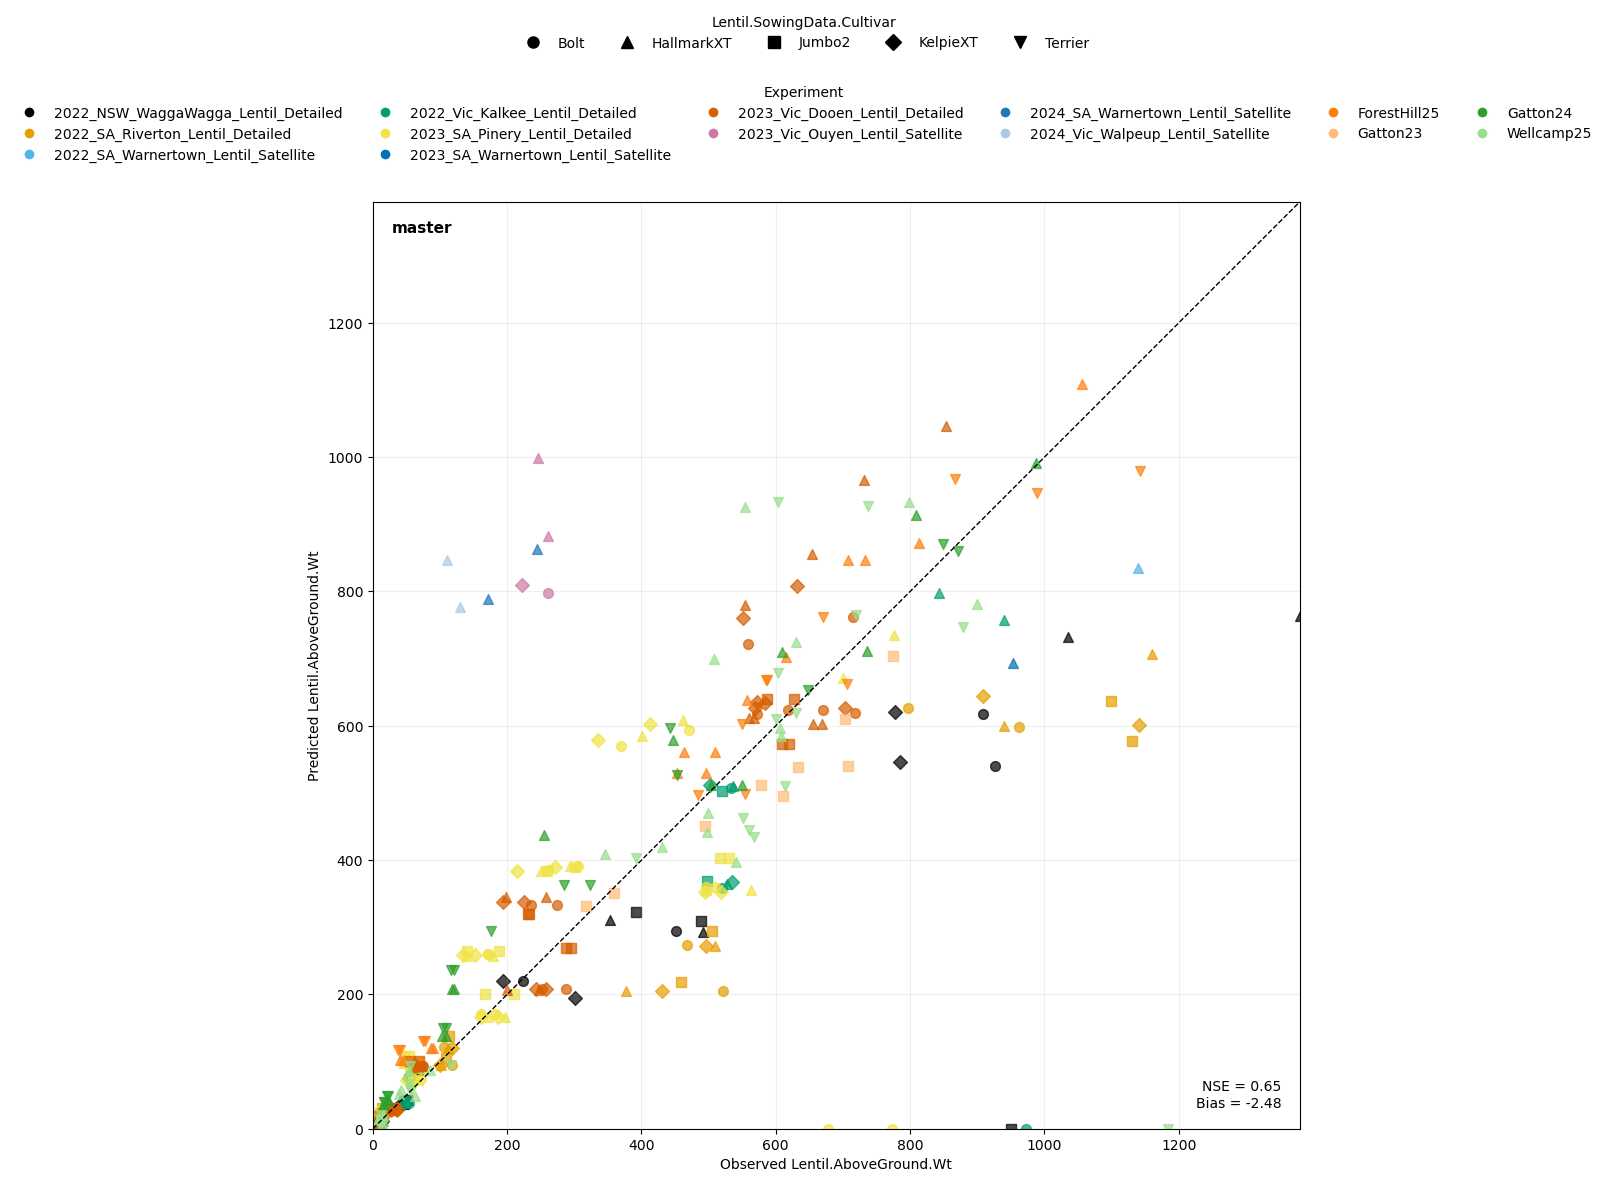

In [78]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config=CONFIG,
    variable = "Lentil.AboveGround.Wt",
    mode="daily",
    #filters = {"Lentil.SowingData.Cultivar": ["HallmarkXT"]},
    color_by = "Experiment",
    marker_by = "Lentil.SowingData.Cultivar",
    size_by=None,
)

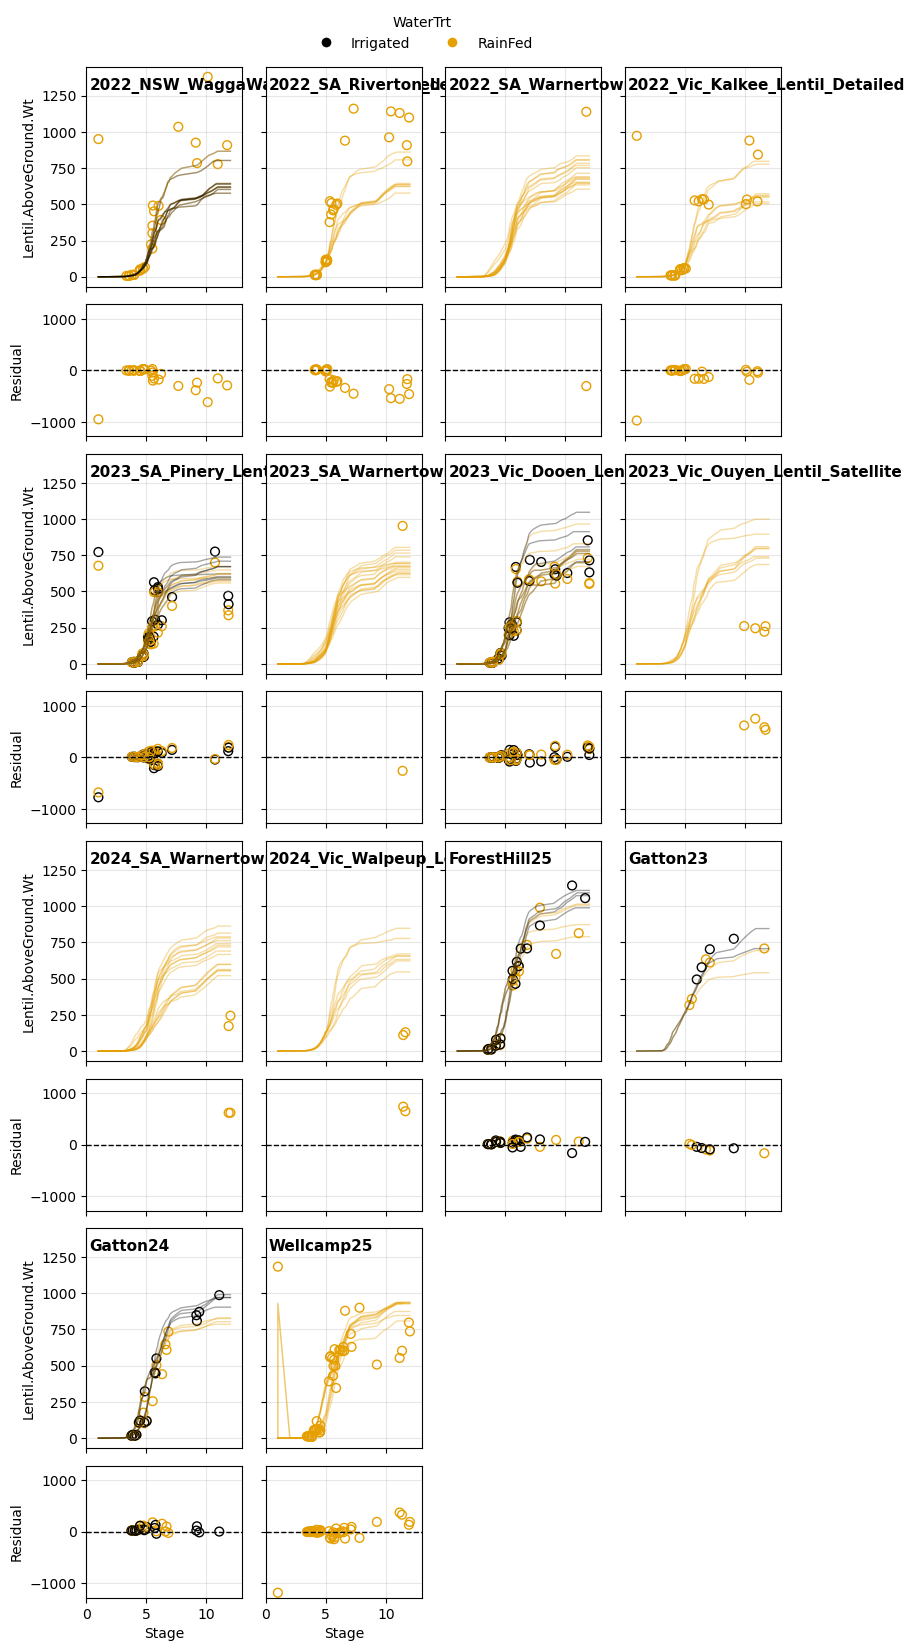

In [79]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Lentil.AboveGround.Wt",
    color_by="WaterTrt",
    marker_by=None,
    panels_by="Experiment",
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Leaf Wt

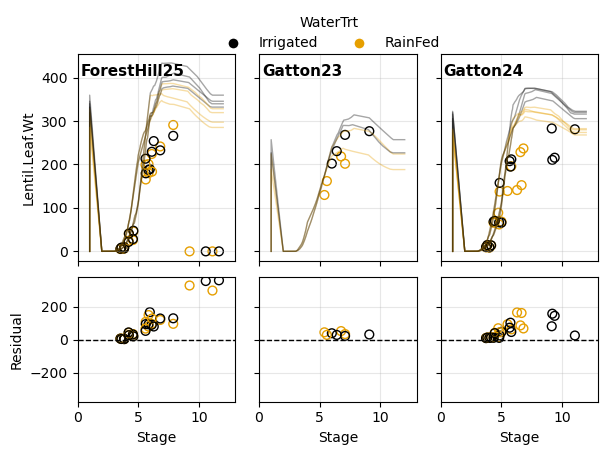

In [80]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Lentil.Leaf.Wt",
    color_by="WaterTrt",
    marker_by=None,
    panels_by="Experiment",
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Stem Wt

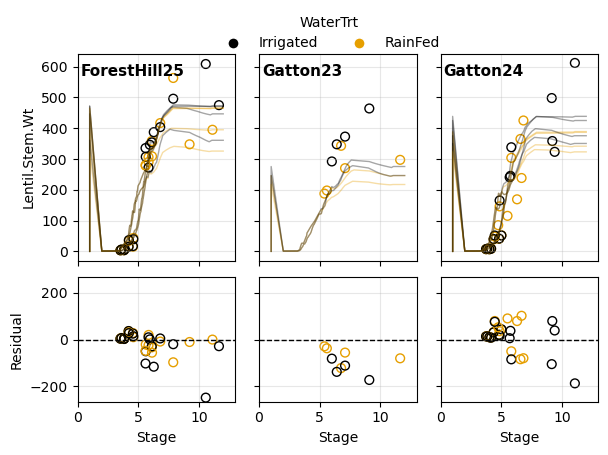

In [81]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Lentil.Stem.Wt",
    color_by="WaterTrt",
    marker_by=None,
    panels_by="Experiment",
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Cover

In [82]:
# plot_stage_timeseries(
#     tidy = tidy,
#     config = CONFIG,
#     variable = "Lentil.Leaf.Canopy.CoverGreen",
#     color_by="WaterTrt",
#     marker_by=None,
#     panels_by="Experiment",
#     max_cols=4,
#     panel_scale=0.8,
# )
# plt.show()

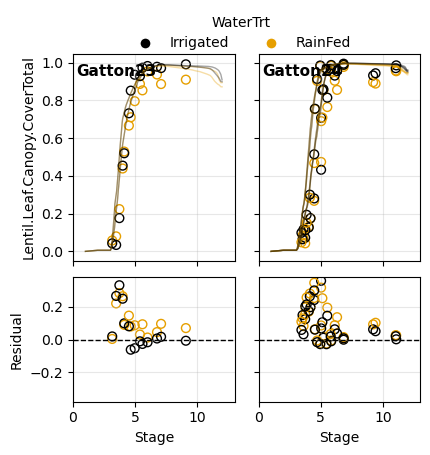

In [83]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Lentil.Leaf.Canopy.CoverTotal",
    color_by="WaterTrt",
    marker_by=None,
    panels_by="Experiment",
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

# Work out list of files to run for each cultivar for phenology fitting

In [84]:
obs = tidy[tidy.type=='obs']
phenVars = ['Lentil.Phenology.StartBuddingDAS',
             'Lentil.Phenology.StartFloweringDAS',
             'Lentil.Phenology.StartPoddingDAS']
phenObs = obs[obs.variable.isin(phenVars)]

In [85]:
phenObs#[phenObs.file=="2024_Vic_Walpeup_Lentil_Satellite.apsimx"]

,CheckpointID,SimulationID,Experiment,Zone,Clock.Today,SimulationName,Lentil.Phenology.CurrentStageName,Lentil.SowingData.Cultivar,type,branch,file,variable,value,ProjectGroup,WaterTrt
2228295,1,3,2022_Vic_Kalkee_Lentil_Detailed,NaN,2022-12-06 00:00:00,2022_Vic_Kalkee_Lentil_DetailedTOSTOS1VarietyB...,HarvestRipe,Bolt,obs,master,2022_Vic_Kalkee_Lentil_Detailed.apsimx,Lentil.Phenology.StartBuddingDAS,107.0,NaPA,RainFed
2228296,1,4,2022_Vic_Kalkee_Lentil_Detailed,NaN,2022-12-06 00:00:00,2022_Vic_Kalkee_Lentil_DetailedTOSTOS2VarietyB...,HarvestRipe,Bolt,obs,master,2022_Vic_Kalkee_Lentil_Detailed.apsimx,Lentil.Phenology.StartBuddingDAS,92.0,NaPA,RainFed
2228297,1,2,2022_Vic_Kalkee_Lentil_Detailed,NaN,2022-12-06 00:00:00,2022_Vic_Kalkee_Lentil_DetailedTOSTOS1VarietyH...,HarvestRipe,HallmarkXT,obs,master,2022_Vic_Kalkee_Lentil_Detailed.apsimx,Lentil.Phenology.StartBuddingDAS,107.0,NaPA,RainFed
2228298,1,1,2022_Vic_Kalkee_Lentil_Detailed,NaN,2022-12-06 00:00:00,2022_Vic_Kalkee_Lentil_DetailedTOSTOS2VarietyH...,HarvestRipe,HallmarkXT,obs,master,2022_Vic_Kalkee_Lentil_Detailed.apsimx,Lentil.Phenology.StartBuddingDAS,92.0,NaPA,RainFed
2228299,1,5,2022_Vic_Kalkee_Lentil_Detailed,NaN,2022-12-06 00:00:00,2022_Vic_Kalkee_Lentil_DetailedTOSTOS1VarietyJ...,HarvestRipe,Jumbo2,obs,master,2022_Vic_Kalkee_Lentil_Detailed.apsimx,Lentil.Phenology.StartBuddingDAS,107.0,NaPA,RainFed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2301579,1,1,2024_Vic_Walpeup_Lentil_Satellite,NaN,2024-11-04 00:00:00,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS2Variet...,HarvestRipe,HallmarkXT,obs,master,2024_Vic_Walpeup_Lentil_Satellite.apsimx,Lentil.Phenology.StartPoddingDAS,98.0,NaPA,RainFed
2301580,1,141,2024_Vic_Walpeup_Lentil_Satellite,NaN,2024-10-24 00:00:00,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,HarvestRipe,Jumbo2,obs,master,2024_Vic_Walpeup_Lentil_Satellite.apsimx,Lentil.Phenology.StartPoddingDAS,120.0,NaPA,RainFed
2301581,1,142,2024_Vic_Walpeup_Lentil_Satellite,NaN,2024-11-04 00:00:00,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS2Variet...,HarvestRipe,Jumbo2,obs,master,2024_Vic_Walpeup_Lentil_Satellite.apsimx,Lentil.Phenology.StartPoddingDAS,98.0,NaPA,RainFed
2301582,1,143,2024_Vic_Walpeup_Lentil_Satellite,NaN,2024-10-24 00:00:00,2024_Vic_Walpeup_Lentil_SatelliteTOSTOS1Variet...,HarvestRipe,KelpieXT,obs,master,2024_Vic_Walpeup_Lentil_Satellite.apsimx,Lentil.Phenology.StartPoddingDAS,119.0,NaPA,RainFed


In [86]:
phenFrame = phenObs.groupby(['Lentil.SowingData.Cultivar','file']).count().index.to_frame()

In [87]:
CvList = phenFrame.index.get_level_values(0).drop_duplicates().values
CvFileDict = {}

for Cv in CvList:
    CvFileDict[Cv] = phenFrame.loc[Cv,'file'].drop_duplicates().to_list()
CvFileDict

{'Ace': ['2022_NSW_Methul_Lentil_Satellite.apsimx',
  '2022_NSW_RankinsSprings_Lentil_Satellite.apsimx'],
 'Bolt': ['2022_NSW_Methul_Lentil_Satellite.apsimx',
  '2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
  '2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_SA_Warnertown_Lentil_Satellite.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2022_Vic_Ouyen_Lentil_Satellite.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_SA_Warnertown_Lentil_Satellite.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  '2023_Vic_Ouyen_Lentil_Satellite.apsimx',
  '2024_SA_Warnertown_Lentil_Satellite.apsimx',
  '2024_Vic_Walpeup_Lentil_Satellite.apsimx'],
 'Greenfield': ['2022_NSW_Methul_Lentil_Satellite.apsimx',
  '2022_NSW_RankinsSprings_Lentil_Satellite.apsimx'],
 'HallmarkXT': ['2022_NSW_Methul_Lentil_Satellite.apsimx',
  '2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
  '2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Ri

# Graph simulated water stress as a check

In [88]:
def plot_timeseries_by_experiment(
    tidy,
    raw,   # kept for compatibility, but NOT used anymore
    variable,
    color_var
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # -------------------------------
    # STEP 1: FILTER TIDY DATA
    # -------------------------------
    df = tidy[
        (tidy["type"] == "pred") &
        (tidy["variable"] == variable)
    ].copy()

    if df.empty:
        raise ValueError(f"No data found for variable '{variable}'")

    # ensure datetime
    df["Clock.Today"] = pd.to_datetime(df["Clock.Today"], errors="coerce")

    # -------------------------------
    # STEP 3: COLOUR RULE
    # -------------------------------
    def get_color(val):
        if val is None or pd.isna(val):
            return "green"

        val = str(val).lower()

        if val == "rainfed":
            return "red"
        elif val == "irrigated":
            return "blue"
        elif val == "rainout":
            return "orange"
        else:
            return "green"

    # -------------------------------
    # STEP 4: CREATE PANELS
    # -------------------------------
    experiments = sorted(df["Experiment"].dropna().unique())

    n = len(experiments)
    if n == 0:
        raise ValueError("No experiments found")

    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(6 * ncols, 4 * nrows),
        sharey=True,
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    # -------------------------------
    # STEP 5: PLOT EACH PANEL
    # -------------------------------
    for ax, exp in zip(axes, experiments):

        exp_df = df[df["Experiment"] == exp]

        if exp_df.empty:
            ax.set_title(f"{exp} (no data)")
            ax.set_axis_off()
            continue

        for sim_name, sub in exp_df.groupby("SimulationName"):

            sub = sub.sort_values("Clock.Today")

            # get water group
            vals = sub["WaterTrt"].dropna().unique()
            val = vals[0] if len(vals) > 0 else None

            color = get_color(val)

            ax.plot(
                sub["Clock.Today"],
                sub["value"],
                color=color,
                alpha=0.7,
                linewidth=1
            )

        ax.set_title(exp)
        ax.set_xlabel("Date")
        ax.set_ylabel(variable)
        ax.grid(alpha=0.2)

    # -------------------------------
    # CLEAN UNUSED PANELS
    # -------------------------------
    for ax in axes[n:]:
        ax.set_visible(False)

    # -------------------------------
    # LEGEND
    # -------------------------------
    import matplotlib.lines as mlines

    handles = [
        mlines.Line2D([], [], color="red", label="RainFed"),
        mlines.Line2D([], [], color="blue", label="Irrigated"),
        mlines.Line2D([], [], color="orange", label="RainOut"),
        mlines.Line2D([], [], color="green", label="Other / Missing"),
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=4,
        frameon=False
    )

    # -------------------------------

    return fig

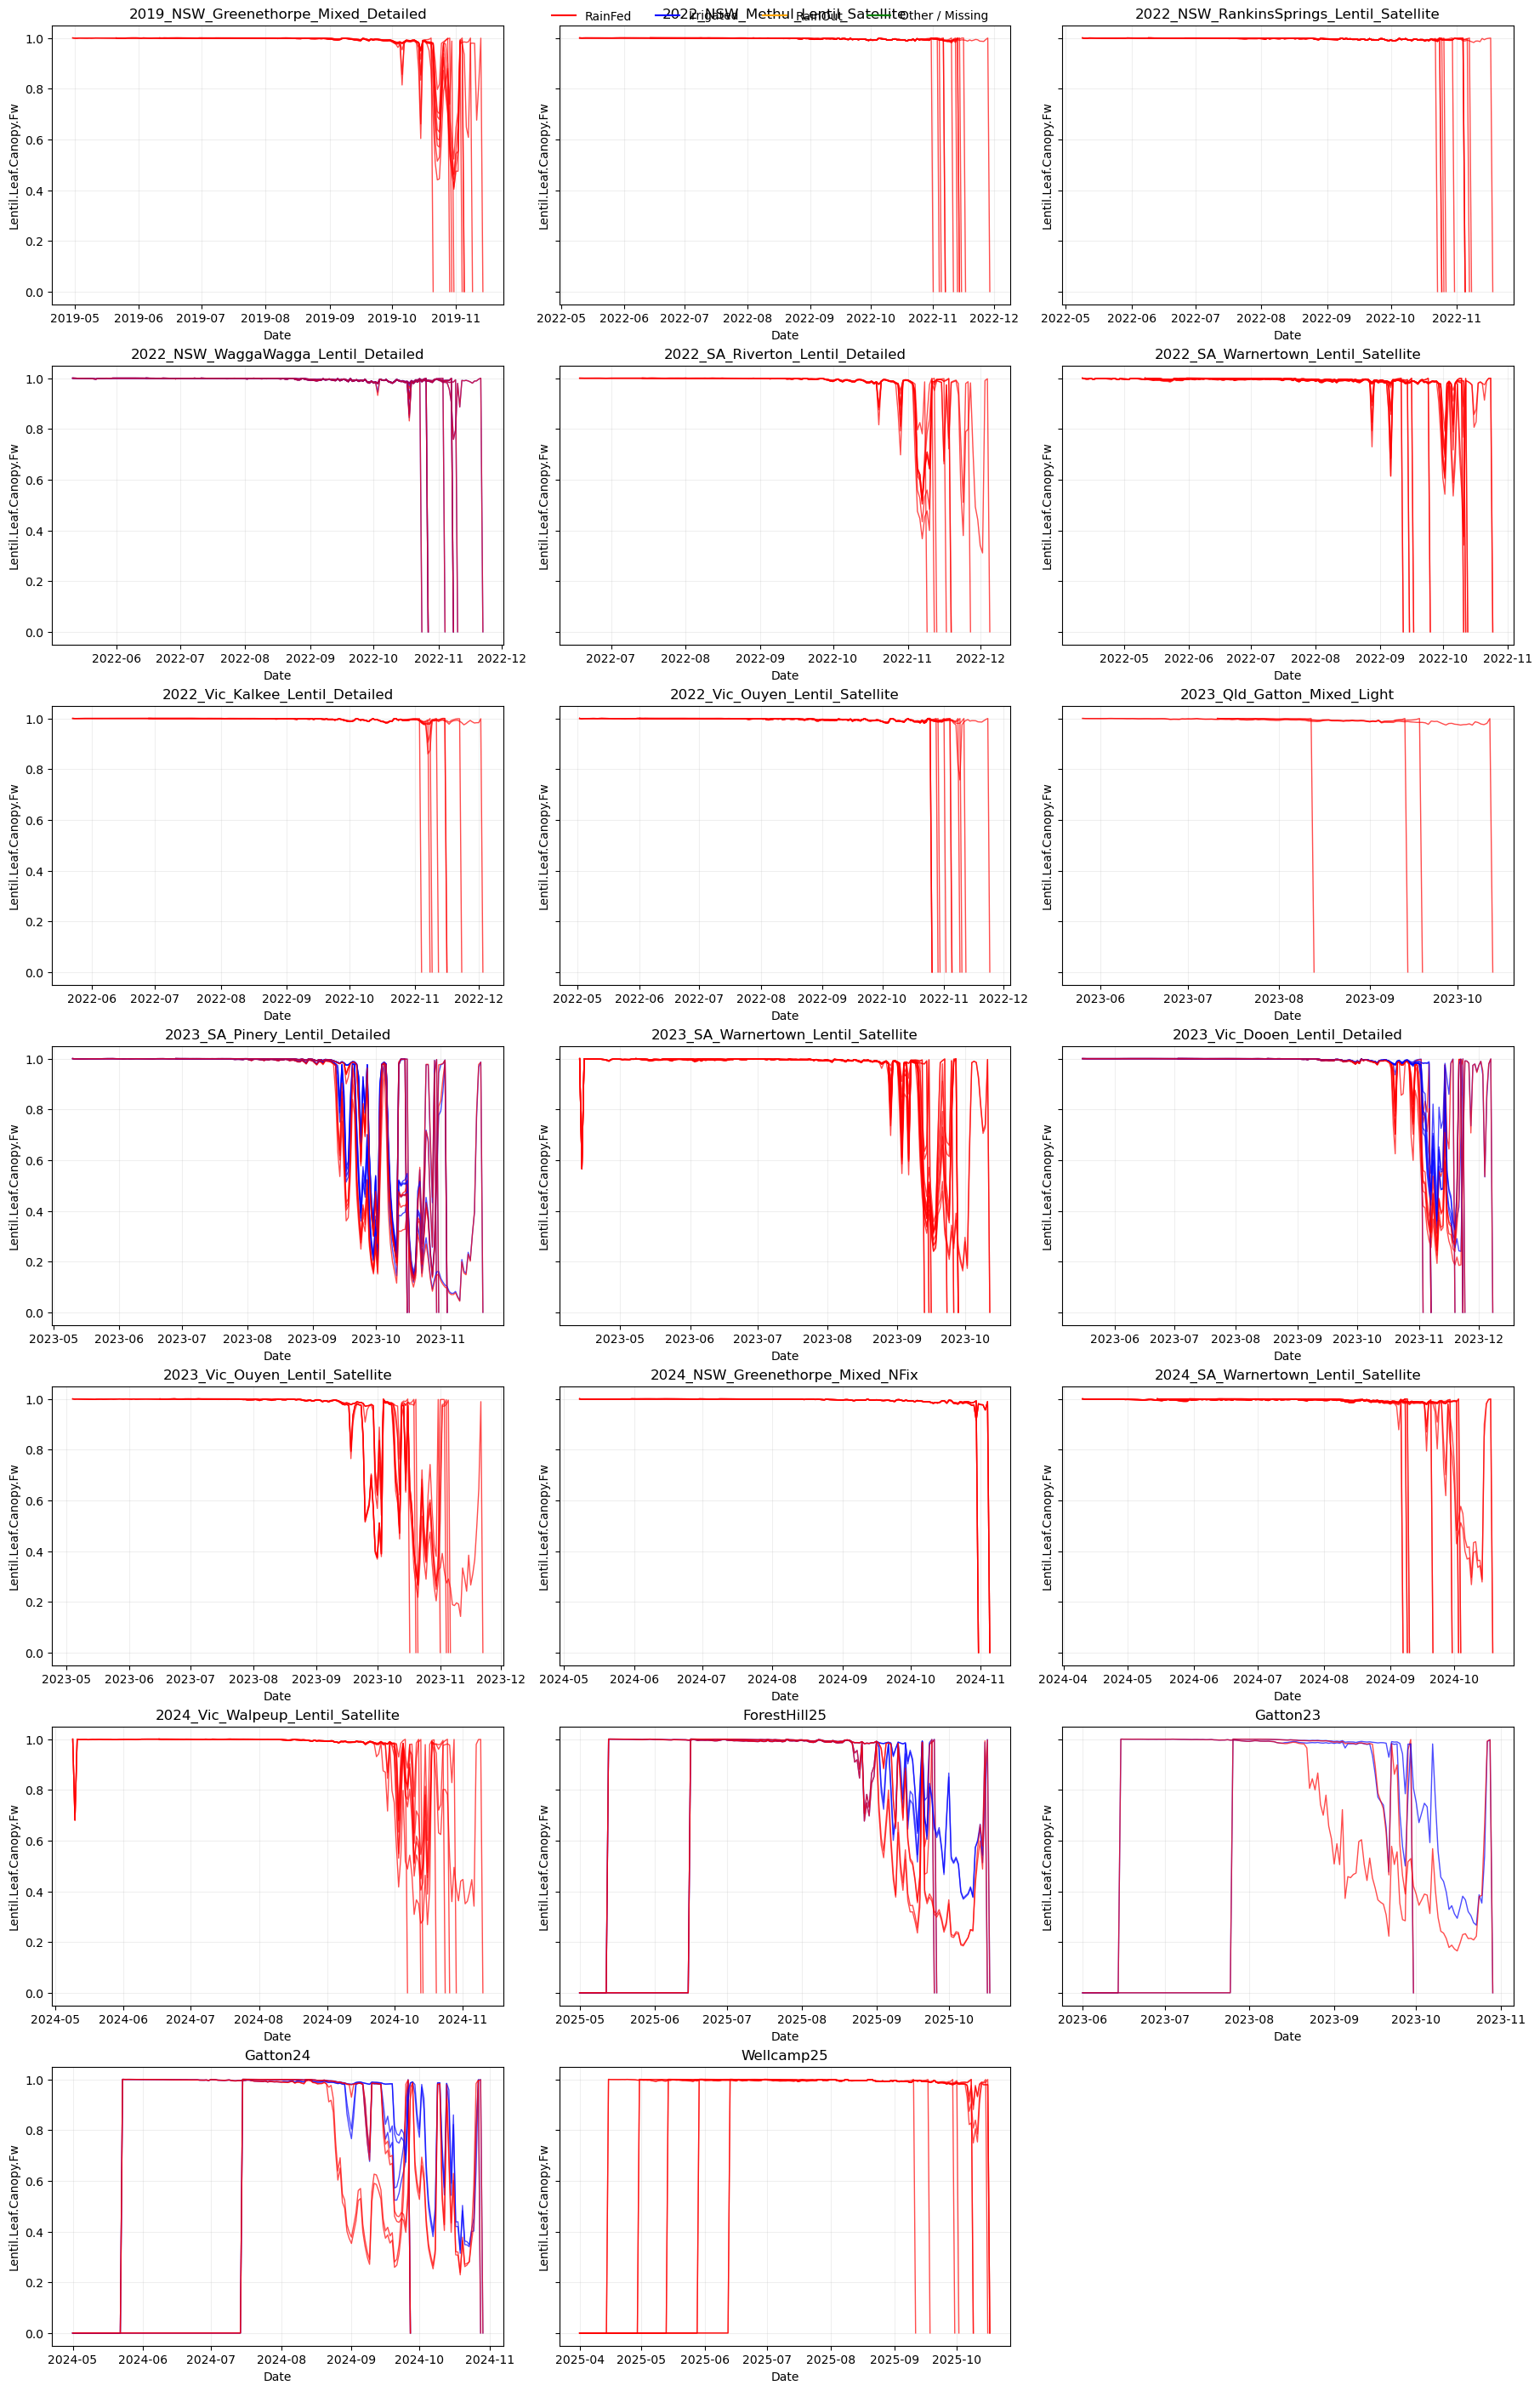

In [89]:
graph = plot_timeseries_by_experiment(
    tidy=tidy,
    raw=raw,
    variable="Lentil.Leaf.Canopy.Fw",
    color_var="WaterTrt"
)

In [ ]:
graph = plot_timeseries_by_experiment(
    tidy=tidy,
    raw=raw,
    variable="Lentil.Phenology.Photoperiod",
    color_var="WaterTrt"
)

In [ ]:
graph = plot_timeseries_by_experiment(
    tidy=tidy,
    raw=raw,
    variable="IWeather.MinT",
    color_var="WaterTrt"
)

### 